# Preventing Data Leakage in Simulated TCSPC Data

This notebook investigates how train-test splitting strategies affect the evaluation of machine-learning models trained on simulated TCSPC decay curves.

Synthetic datasets often contain several Poisson-noisy realizations generated from the same underlying physical parameters. If these closely related curves are randomly distributed between the training and test sets, the resulting evaluation may be unrealistically optimistic.

The notebook compares:

* an ordinary random row-level split;
* a group-aware split based on simulation parameter sets;
* a lifetime-interval holdout experiment;
* a noise-robustness experiment.

The purpose is to distinguish performance on familiar parameter regions from robustness to genuinely unfamiliar physical or statistical conditions.

## 1. Scientific motivation

A supervised machine-learning model is normally trained on one subset of a dataset and evaluated on another subset that was not used during training.

For the evaluation to be scientifically meaningful, the test samples should represent genuinely unseen information.

In simulated TCSPC datasets, however, multiple measured curves may be generated from the same expected decay curve. For example, several Poisson-noisy realizations may share exactly the same:

* fluorescence lifetime;
* decay amplitude;
* background level;
* time axis;
* decay model.

Only the random Poisson realization differs between these curves.

Consider three simulated curves generated using the same physical parameters:

- lifetime: 2.5 ns
- amplitude: 10,000 counts
- background: 5 counts per bin

The corresponding measured curves may differ because independent Poisson noise is applied:

| Curve | Parameter set | Random seed |
|---:|---|---:|
| 1 | A | 101 |
| 2 | A | 102 |
| 3 | A | 103 |

An ordinary random train-test split may assign curves 1 and 2 to the training set and curve 3 to the test set.

Although curve 3 was not directly used during training, it originates from the same expected decay curve as curves 1 and 2.

The model is therefore tested on a sample that is statistically new but physically almost identical to samples already present in the training set.

This problem is not classical target leakage because the true lifetime is not directly included among the model input features.

Instead, it is a form of **simulation-group leakage** or **dependence between training and test samples**.

The training and test sets are not sufficiently independent because they contain different noisy realizations of the same underlying simulation parameter set.

A model evaluated under these conditions may achieve a very small test error without demonstrating that it can generalize to:

* unseen lifetime values;
* unseen combinations of lifetime, amplitude, and background;
* lower photon-count conditions;
* stronger background noise;
* different decay models;
* unfamiliar instrument-response functions.

It is therefore important to define what kind of generalization each evaluation experiment is intended to measure.

In this notebook, four generalization concepts are distinguished.

### Interpolation performance

The test data lie within the physical parameter ranges represented during training, but the exact simulation parameter combinations are new.

### Robustness to new noise levels

The physical decay model remains unchanged, but the test curves contain photon counts or background levels not represented during training.

### Robustness to model mismatch

The test curves do not exactly follow the decay model used to generate the training data. For example, a model trained on mono-exponential curves may later be tested on bi-exponential curves.

### Robustness to unfamiliar IRFs

After instrument-response-function convolution is added to the toolkit, a model may be trained using one family of IRFs and evaluated using different IRF
shapes or widths.

The main question throughout this notebook is:

> What exactly is unfamiliar to the model in the test set?

A test set may differ from the training set only through a new Poisson realization, or it may introduce a genuinely new physical or statistical
condition.

These situations support different scientific claims and should therefore be evaluated separately.

In [1]:
from pathlib import Path
from math import comb

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.ensemble import (
    GradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    median_absolute_error,
    r2_score,
)
from sklearn.model_selection import (
    GroupShuffleSplit,
    train_test_split,
)

from tcspc_toolkit.models import monoexponential_decay
from tcspc_toolkit.simulation import sample_photon_counts

## 2. Generation of repeated noise realizations

To demonstrate the difference between row-level and group-aware splitting, this
notebook requires a dataset containing several measured curves for each
underlying physical parameter combination.

For one parameter group, the lifetime, amplitude, background, time axis, and
expected decay curve remain fixed. Multiple measured curves are then generated
by applying independent Poisson sampling to that same expected curve.

The resulting hierarchy is:

```text
simulation parameter group
├── Poisson realization 1
├── Poisson realization 2
├── Poisson realization 3
└── ...
```

Curves belonging to one group are not numerically identical because every Poisson realization is independently sampled. Nevertheless, they share the same underlying expected decay and are therefore more closely related than curves generated from different physical parameter combinations.

### Why we need both identifiers

We will eventually have metadata similar to:

| `curve_id` | `parameter_group` | `realization_id` | `lifetime_ns` |
|---:|---:|---:|---:|
| 0 | 0 | 0 | 1.25 |
| 1 | 0 | 1 | 1.25 |
| 2 | 0 | 2 | 1.25 |
| 3 | 1 | 0 | 2.50 |

Three identifiers will be retained

- `curve_id` uniquely identifies every measured histogram;
- `parameter_group` identifies the shared expected decay;
- `realization_id` identifies the Poisson draw inside that group.

The `parameter_group` variable will later be used to ensure that all realizations of one expected decay are assigned either to the training set or to the test set, but never to both.

In [2]:
n_time_bins = 256
start_time_ns = 0.0
end_time_ns = 12.0

time_ns = np.linspace(
    start_time_ns,
    end_time_ns,
    n_time_bins,
    dtype=np.float64,
)

n_parameter_groups = 500
n_realizations_per_group = 5

lifetime_range_ns = (0.5, 5.0)
amplitude_range = (500.0, 10_000.0)
background_range = (0.0, 10.0)

random_seed = 42
rng = np.random.default_rng(random_seed)

In [3]:
n_curves = n_parameter_groups * n_realizations_per_group

print(f"Number of parameter groups: {n_parameter_groups}")
print(f"Realizations per group: {n_realizations_per_group}")
print(f"Total number of curves: {n_curves}")
print(f"Number of time bins: {n_time_bins}")
print(f"Input-matrix shape: ({n_curves}, {n_time_bins})")

Number of parameter groups: 500
Realizations per group: 5
Total number of curves: 2500
Number of time bins: 256
Input-matrix shape: (2500, 256)


### Sample parameter groups

In [4]:
group_lifetimes_ns = rng.uniform(
    low=lifetime_range_ns[0],
    high=lifetime_range_ns[1],
    size=n_parameter_groups,
)

group_amplitudes = rng.uniform(
    low=amplitude_range[0],
    high=amplitude_range[1],
    size=n_parameter_groups,
)

group_backgrounds = rng.uniform(
    low=background_range[0],
    high=background_range[1],
    size=n_parameter_groups,
)

In [5]:
parameter_table = pd.DataFrame(
    {
        "parameter_group": np.arange(
            n_parameter_groups,
            dtype=np.int64,
        ),
        "lifetime_ns": group_lifetimes_ns,
        "amplitude": group_amplitudes,
        "background": group_backgrounds,
    }
)

parameter_table.head()

,parameter_group,lifetime_ns,amplitude,background
0,0,3.982802,7498.704041,0.620631
1,1,2.474953,8920.827424,4.582620
2,2,4.363691,9250.043374,1.290301
3,3,3.638156,5284.512789,1.523267
4,4,0.923798,5442.613590,6.322828


In [6]:
parameter_table.describe()

,parameter_group,lifetime_ns,amplitude,background
count,500.000000,500.000000,500.000000,500.000000
mean,249.500000,2.730566,5237.406222,5.045747
std,144.481833,1.290476,2817.704575,2.915219
min,0.000000,0.524434,511.714094,0.005187
25%,124.750000,1.561917,2811.523587,2.460615
50%,249.500000,2.754018,5190.300206,4.924648
75%,374.250000,3.862599,7752.092448,7.590803
max,499.000000,4.995971,9988.062016,9.994219


In [7]:
assert np.all(group_lifetimes_ns >= lifetime_range_ns[0])
assert np.all(group_lifetimes_ns < lifetime_range_ns[1])

assert np.all(group_amplitudes >= amplitude_range[0])
assert np.all(group_amplitudes < amplitude_range[1])

assert np.all(group_backgrounds >= background_range[0])
assert np.all(group_backgrounds < background_range[1])

In [8]:
measured_curves = np.empty(
    shape=(n_curves, n_time_bins),
    dtype=np.int64,
)

expected_curves = np.empty(
    shape=(n_parameter_groups, n_time_bins),
    dtype=np.float64,
)

In [9]:
curve_ids = np.arange(n_curves, dtype=np.int64)

parameter_groups = np.empty(
    n_curves,
    dtype=np.int64,
)

realization_ids = np.empty(
    n_curves,
    dtype=np.int64,
)

curve_lifetimes_ns = np.empty(
    n_curves,
    dtype=np.float64,
)

curve_amplitudes = np.empty(
    n_curves,
    dtype=np.float64,
)

curve_backgrounds = np.empty(
    n_curves,
    dtype=np.float64,
)

### Generate the grouped curves

In [10]:
curve_id = 0

for parameter_group in range(n_parameter_groups):
    lifetime_ns = group_lifetimes_ns[parameter_group]
    amplitude = group_amplitudes[parameter_group]
    background = group_backgrounds[parameter_group]

    expected_counts = monoexponential_decay(
        time=time_ns,
        amplitude=amplitude,
        lifetime=lifetime_ns,
        background=background,
    )

    expected_curves[parameter_group] = expected_counts

    for realization_id in range(n_realizations_per_group):
        measured_counts = sample_photon_counts(
            expected_counts=expected_counts,
            rng=rng,
        )

        measured_curves[curve_id] = measured_counts
        parameter_groups[curve_id] = parameter_group
        realization_ids[curve_id] = realization_id
        curve_lifetimes_ns[curve_id] = lifetime_ns
        curve_amplitudes[curve_id] = amplitude
        curve_backgrounds[curve_id] = background

        curve_id += 1

In [11]:
assert curve_id == n_curves
assert measured_curves.shape == (n_curves, n_time_bins)
assert expected_curves.shape == (
    n_parameter_groups,
    n_time_bins,
)

In [12]:
curve_metadata = pd.DataFrame(
    {
        "curve_id": curve_ids,
        "parameter_group": parameter_groups,
        "realization_id": realization_ids,
        "lifetime_ns": curve_lifetimes_ns,
        "amplitude": curve_amplitudes,
        "background": curve_backgrounds,
        "measured_total_counts": measured_curves.sum(axis=1),
    }
)

curve_metadata.head(10)

,curve_id,parameter_group,realization_id,lifetime_ns,amplitude,background,measured_total_counts
0,0,0,0,3.982802,7498.704041,0.620631,608338
1,1,0,1,3.982802,7498.704041,0.620631,607223
2,2,0,2,3.982802,7498.704041,0.620631,606840
3,3,0,3,3.982802,7498.704041,0.620631,608589
4,4,0,4,3.982802,7498.704041,0.620631,607563
5,5,1,0,2.474953,8920.827424,4.582620,470429
6,6,1,1,2.474953,8920.827424,4.582620,470395
7,7,1,2,2.474953,8920.827424,4.582620,470939
8,8,1,3,2.474953,8920.827424,4.582620,471519
9,9,1,4,2.474953,8920.827424,4.582620,470882


In [13]:
group_sizes = curve_metadata.groupby(
    "parameter_group"
).size()

assert group_sizes.nunique() == 1
assert group_sizes.iloc[0] == n_realizations_per_group

In [14]:
within_group_parameter_counts = (
    curve_metadata.groupby("parameter_group")[
        ["lifetime_ns", "amplitude", "background"]
    ]
    .nunique()
)

assert np.all(
    within_group_parameter_counts.to_numpy() == 1
)

In [15]:
first_group_indices = np.flatnonzero(
    parameter_groups == 0
)

first_group_curves = measured_curves[
    first_group_indices
]

n_unique_curves_in_first_group = np.unique(
    first_group_curves,
    axis=0,
).shape[0]

print(
    "Unique measured curves in the first group:",
    n_unique_curves_in_first_group,
)

Unique measured curves in the first group: 5


### Visual comparison of repeated realizations

The curves below belong to one simulation parameter group. They therefore share the same lifetime, amplitude, background, and expected decay. Their visible differences arise only from independent Poisson sampling.

This illustrates why the curves are neither exact duplicates nor fully independent physical cases.


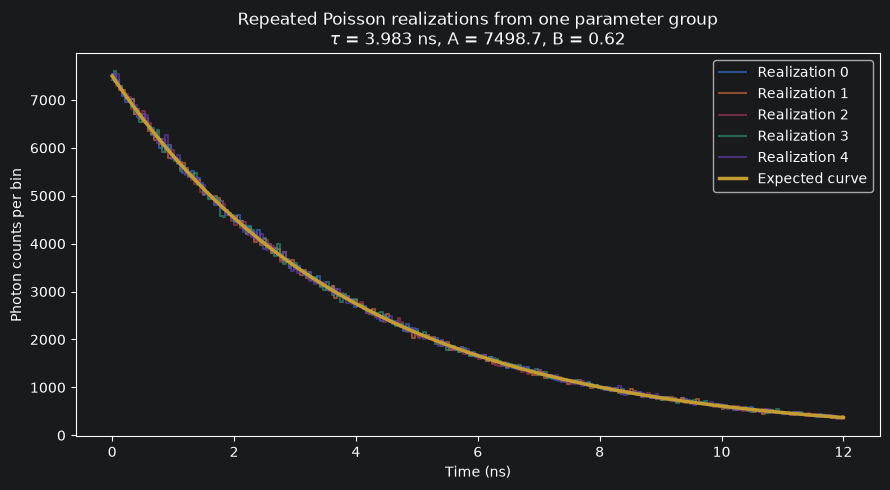

In [16]:
selected_group = 0

selected_indices = np.flatnonzero(
    parameter_groups == selected_group
)

selected_lifetime = group_lifetimes_ns[selected_group]
selected_amplitude = group_amplitudes[selected_group]
selected_background = group_backgrounds[selected_group]

plt.figure(figsize=(9, 5))

for index in selected_indices:
    realization_id = realization_ids[index]

    plt.step(
        time_ns,
        measured_curves[index],
        where="mid",
        alpha=0.65,
        label=f"Realization {realization_id}",
    )

plt.plot(
    time_ns,
    expected_curves[selected_group],
    linewidth=2.5,
    label="Expected curve",
)

plt.xlabel("Time (ns)")
plt.ylabel("Photon counts per bin")
plt.title(
    "Repeated Poisson realizations from one parameter group\n"
    f"$\\tau$ = {selected_lifetime:.3f} ns, "
    f"A = {selected_amplitude:.1f}, "
    f"B = {selected_background:.2f}"
)
plt.legend()
plt.tight_layout()
plt.show()

### Preparation of model inputs

As in the first machine-learning baseline, each measured histogram is normalized by its total photon count:

$$
x_{i,j}^{\mathrm{norm}}
=
\frac{x_{i,j}}{\sum_k x_{i,k}},
$$

where \(i\) indexes the decay curve, \(j\) indexes the time bin, and the sum runs over all time bins \(k\) of curve \(i\).

This removes the overall count scale and makes the initial model input primarily represent the temporal shape of each decay. The unnormalized total photon count is retained separately in the metadata for later noise-dependent evaluation.

Because each curve is normalized using only its own measured counts, this operation does not estimate parameters from the complete dataset and therefore does not transfer population-level information between training and test sets.


In [17]:
curve_totals = measured_curves.sum(
    axis=1,
    keepdims=True,
)

if np.any(curve_totals == 0):
    raise ValueError(
        "At least one simulated curve contains zero total counts."
    )

X = (
    measured_curves.astype(np.float64)
    / curve_totals
)

y = curve_lifetimes_ns.copy()
groups = parameter_groups.copy()

In [18]:
row_sums = X.sum(axis=1)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("groups shape:", groups.shape)
print("Minimum normalized row sum:", row_sums.min())
print("Maximum normalized row sum:", row_sums.max())

assert np.allclose(row_sums, 1.0)

X shape: (2500, 256)
y shape: (2500,)
groups shape: (2500,)
Minimum normalized row sum: 0.9999999999999996
Maximum normalized row sum: 1.0000000000000004


## 3. Naive row-wise random split

A conventional machine-learning workflow often treats every row of the feature matrix as an independent observation and randomly assigns rows to training and
test subsets.

For the present dataset, such a split operates at the level of individual Poisson realizations:

```text
curve 0  ──► training or test
curve 1  ──► training or test
curve 2  ──► training or test
```

The splitting algorithm does not know that several rows may share the same lifetime, amplitude, background, and expected decay curve. It therefore does not prevent different realizations from one parameter group from appearing in both subsets.

This section intentionally applies that naive row-wise strategy. It provides a reference evaluation protocol that will later be compared with a group-aware split.

The split is performed using row indices. Retaining the indices makes it possible to apply exactly the same assignment to the feature matrix, target array, group labels, and metadata table.

The phrase **naive** does not mean that `train_test_split()` is generally a bad function. It means that row-wise splitting is naive **for this particular hierarchical dataset** because the rows are not independent physical cases.

In [19]:
random_test_size = 0.20
split_random_state = 42

all_indices = np.arange(
    X.shape[0],
    dtype=np.int64,
)

(
    random_train_indices,
    random_test_indices,
) = train_test_split(
    all_indices,
    test_size=random_test_size,
    random_state=split_random_state,
    shuffle=True,
)

In [20]:
print(
    "Number of random training indices:",
    random_train_indices.size,
)
print(
    "Number of random test indices:",
    random_test_indices.size,
)
print(
    "Total number of assigned indices:",
    random_train_indices.size
    + random_test_indices.size,
)

Number of random training indices: 2000
Number of random test indices: 500
Total number of assigned indices: 2500


In [21]:
assert random_train_indices.size == 2000
assert random_test_indices.size == 500

assert np.intersect1d(
    random_train_indices,
    random_test_indices,
).size == 0

combined_random_indices = np.concatenate(
    [
        random_train_indices,
        random_test_indices,
    ]
)

assert np.array_equal(
    np.sort(combined_random_indices),
    all_indices,
)

In [22]:
X_train_random = X[random_train_indices]
X_test_random = X[random_test_indices]

y_train_random = y[random_train_indices]
y_test_random = y[random_test_indices]

groups_train_random = groups[random_train_indices]
groups_test_random = groups[random_test_indices]

In [23]:
metadata_train_random = (
    curve_metadata
    .iloc[random_train_indices]
    .reset_index(drop=True)
)

metadata_test_random = (
    curve_metadata
    .iloc[random_test_indices]
    .reset_index(drop=True)
)

In [24]:
print("Random row-level split")
print("----------------------")
print("X_train shape:", X_train_random.shape)
print("X_test shape: ", X_test_random.shape)
print("y_train shape:", y_train_random.shape)
print("y_test shape: ", y_test_random.shape)
print(
    "Training metadata shape:",
    metadata_train_random.shape,
)
print(
    "Test metadata shape:    ",
    metadata_test_random.shape,
)

Random row-level split
----------------------
X_train shape: (2000, 256)
X_test shape:  (500, 256)
y_train shape: (2000,)
y_test shape:  (500,)
Training metadata shape: (2000, 7)
Test metadata shape:     (500, 7)


In [25]:
assert X_train_random.shape == (
    random_train_indices.size,
    n_time_bins,
)

assert X_test_random.shape == (
    random_test_indices.size,
    n_time_bins,
)

assert y_train_random.shape == (
    random_train_indices.size,
)

assert y_test_random.shape == (
    random_test_indices.size,
)

assert groups_train_random.shape == y_train_random.shape
assert groups_test_random.shape == y_test_random.shape

assert len(metadata_train_random) == X_train_random.shape[0]
assert len(metadata_test_random) == X_test_random.shape[0]

assert (
    X_train_random.shape[0]
    + X_test_random.shape[0]
    == n_curves
)

In [26]:
assert np.array_equal(
    metadata_train_random["curve_id"].to_numpy(),
    curve_ids[random_train_indices],
)

assert np.array_equal(
    metadata_test_random["curve_id"].to_numpy(),
    curve_ids[random_test_indices],
)

assert np.allclose(
    metadata_train_random["lifetime_ns"].to_numpy(),
    y_train_random,
)

assert np.allclose(
    metadata_test_random["lifetime_ns"].to_numpy(),
    y_test_random,
)

assert np.array_equal(
    metadata_train_random[
        "parameter_group"
    ].to_numpy(),
    groups_train_random,
)

assert np.array_equal(
    metadata_test_random[
        "parameter_group"
    ].to_numpy(),
    groups_test_random,
)

In [27]:
metadata_train_random.head()

,curve_id,parameter_group,realization_id,lifetime_ns,amplitude,background,measured_total_counts
0,2055,411,0,3.425563,8828.752574,9.758975,629889
1,1961,392,1,3.147161,2814.169081,1.175044,186123
2,1864,372,4,2.138864,9802.634020,4.049941,449726
3,2326,465,1,3.648992,5079.292216,6.728534,384421
4,461,92,1,2.507703,3421.583188,2.893201,183871


In [28]:
metadata_test_random.head()

,curve_id,parameter_group,realization_id,lifetime_ns,amplitude,background,measured_total_counts
0,1447,289,2,0.957524,6206.972229,5.679342,131035
1,1114,222,4,3.482889,840.506138,8.945115,62958
2,1064,212,4,1.398990,8239.065210,5.612231,250988
3,2287,457,2,2.563523,5417.784452,4.378416,295417
4,1537,307,2,3.378035,2142.967396,6.689477,152135


### Target distributions under the random split

Because rows are assigned randomly, the training and test subsets are expected to contain similar lifetime distributions. Similar target distributions are useful for measuring interpolation within the simulated lifetime range.

However, distributional similarity alone does not guarantee independence. Training and test curves may have similar lifetime distributions either because they contain different physical parameter combinations or because they contain different Poisson realizations of the same combinations.

In [29]:
random_target_summary = pd.DataFrame(
    {
        "training": pd.Series(y_train_random).describe(),
        "test": pd.Series(y_test_random).describe(),
    }
)

random_target_summary

,training,test
count,2000.000000,500.000000
mean,2.740038,2.692678
std,1.282975,1.315618
min,0.524434,0.524434
25%,1.584368,1.397223
50%,2.754701,2.708181
75%,3.868736,3.832408
max,4.995971,4.995971


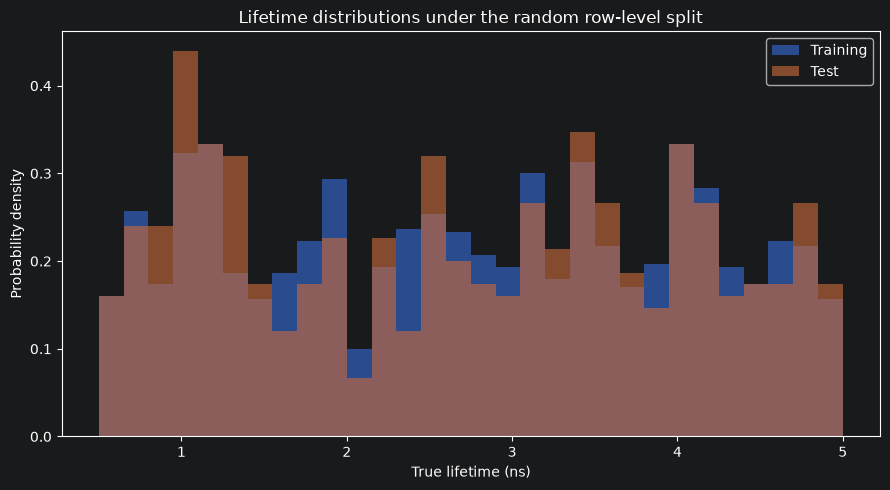

In [30]:
lifetime_bin_edges = np.linspace(
    lifetime_range_ns[0],
    lifetime_range_ns[1],
    31,
)

plt.figure(figsize=(9, 5))

plt.hist(
    y_train_random,
    bins=lifetime_bin_edges,
    density=True,
    alpha=0.6,
    label="Training",
)

plt.hist(
    y_test_random,
    bins=lifetime_bin_edges,
    density=True,
    alpha=0.6,
    label="Test",
)

plt.xlabel("True lifetime (ns)")
plt.ylabel("Probability density")
plt.title(
    "Lifetime distributions under the random row-level split"
)
plt.legend()
plt.tight_layout()
plt.show()

### Photon-count distributions under the random split

The total number of measured photons influences the magnitude of relative Poisson fluctuations. It is therefore useful to verify whether the random split creates comparable photon-count distributions in the training and test sets.

At this stage, the purpose is descriptive. A dedicated experiment with deliberately separated photon-count regimes will be performed later to evaluate robustness to new noise conditions.

In [31]:
train_total_counts_random = (
    metadata_train_random[
        "measured_total_counts"
    ].to_numpy()
)

test_total_counts_random = (
    metadata_test_random[
        "measured_total_counts"
    ].to_numpy()
)

In [32]:
random_count_summary = pd.DataFrame(
    {
        "training": pd.Series(
            train_total_counts_random
        ).describe(),
        "test": pd.Series(
            test_total_counts_random
        ).describe(),
    }
)

random_count_summary

,training,test
count,2000.000000,500.000000
mean,290704.579000,298243.190000
std,209377.580315,223476.151279
min,12448.000000,15169.000000
25%,124598.000000,124628.750000
50%,233945.000000,219912.000000
75%,424766.250000,453437.000000
max,933951.000000,931607.000000


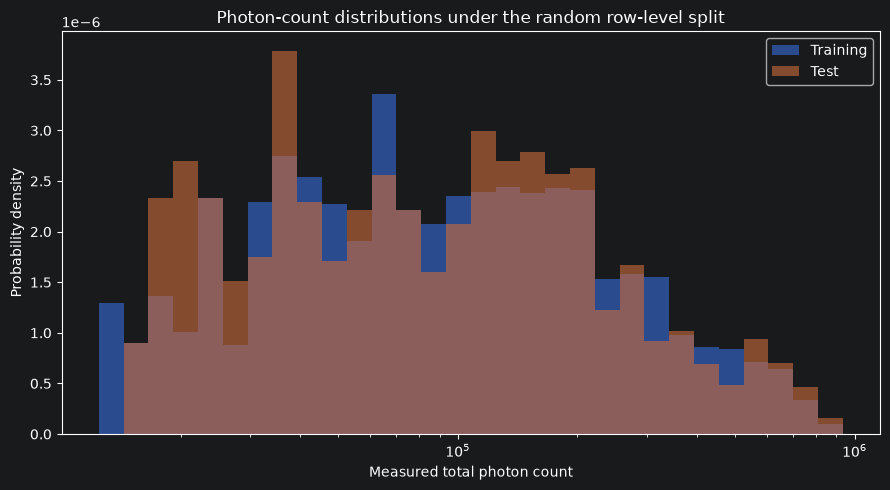

In [33]:
positive_total_counts = curve_metadata.loc[
    curve_metadata["measured_total_counts"] > 0,
    "measured_total_counts",
].to_numpy()

count_bin_edges = np.geomspace(
    positive_total_counts.min(),
    positive_total_counts.max(),
    31,
)

plt.figure(figsize=(9, 5))

plt.hist(
    train_total_counts_random,
    bins=count_bin_edges,
    density=True,
    alpha=0.6,
    label="Training",
)

plt.hist(
    test_total_counts_random,
    bins=count_bin_edges,
    density=True,
    alpha=0.6,
    label="Test",
)

plt.xscale("log")
plt.xlabel("Measured total photon count")
plt.ylabel("Probability density")
plt.title(
    "Photon-count distributions under the random row-level split"
)
plt.legend()
plt.tight_layout()
plt.show()

In [34]:
n_train_groups_random = np.unique(
    groups_train_random
).size

n_test_groups_random = np.unique(
    groups_test_random
).size

print(
    "Unique parameter groups represented in training:",
    n_train_groups_random,
)
print(
    "Unique parameter groups represented in test:",
    n_test_groups_random,
)
print(
    "Total parameter groups in the dataset:",
    n_parameter_groups,
)

Unique parameter groups represented in training: 500
Unique parameter groups represented in test: 329
Total parameter groups in the dataset: 500


### Interpretation of the naive split

The random row-level procedure creates two disjoint sets of measured curves:

* no individual histogram appears in both subsets;
* all curves are assigned exactly once;
* the training and test subsets have similar lifetime distributions;
* the training and test subsets have similar photon-count distributions.

These properties make the split look statistically reasonable when each row is treated as an independent observation.

However, row-level disjointness is not equivalent to parameter-group disjointness. Because the splitting algorithm ignored `parameter_group`, different Poisson realizations of the same expected decay may occur in both subsets.

The random split therefore answers the relatively limited question:

> How accurately can the model predict randomly withheld Poisson realizations
> drawn from the same overall simulation campaign?

It does not necessarily answer the stronger question:

> How accurately can the model predict curves generated from unfamiliar
> physical parameter combinations?

The next section constructs a group-aware split in which all realizations from one parameter group are kept together.

## 4. Parameter-group split

The naive split treated every measured histogram as an independent row. A group-aware split instead treats the underlying simulation parameter set as the indivisible observation.

All Poisson realizations generated from one expected decay must be assigned to the same subset:

```text
parameter group
├── realization 0
├── realization 1
├── realization 2
├── realization 3
└── realization 4
        ↓
training or test, but not both
```

This prevents the model from being trained on one noisy realization of an expected decay and tested on another realization of that same decay. The split will be created using `GroupShuffleSplit`. The feature matrix and target values are still divided at the curve level, but the group labels constrain which curves may be separated.

The key distinction is:

```text
Naive split:
individual rows are shuffled independently

Group-aware split:
groups are shuffled, and rows follow their groups
```

In [35]:
group_test_size = 0.20
group_split_random_state = 42

group_splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=group_test_size,
    random_state=group_split_random_state,
)

(
    grouped_train_indices,
    grouped_test_indices,
) = next(
    group_splitter.split(
        X,
        y,
        groups=groups,
    )
)

In [36]:
print(
    "Number of grouped training indices:",
    grouped_train_indices.size,
)
print(
    "Number of grouped test indices:",
    grouped_test_indices.size,
)
print(
    "Total number of assigned indices:",
    grouped_train_indices.size
    + grouped_test_indices.size,
)

Number of grouped training indices: 2000
Number of grouped test indices: 500
Total number of assigned indices: 2500


In [37]:
assert (
    grouped_train_indices.size
    + grouped_test_indices.size
    == n_curves
)

assert np.intersect1d(
    grouped_train_indices,
    grouped_test_indices,
).size == 0

combined_grouped_indices = np.concatenate(
    [
        grouped_train_indices,
        grouped_test_indices,
    ]
)

assert np.array_equal(
    np.sort(combined_grouped_indices),
    all_indices,
)

In [38]:
X_train_grouped = X[grouped_train_indices]
X_test_grouped = X[grouped_test_indices]

y_train_grouped = y[grouped_train_indices]
y_test_grouped = y[grouped_test_indices]

groups_train_grouped = groups[grouped_train_indices]
groups_test_grouped = groups[grouped_test_indices]

In [39]:
metadata_train_grouped = (
    curve_metadata
    .iloc[grouped_train_indices]
    .reset_index(drop=True)
)

metadata_test_grouped = (
    curve_metadata
    .iloc[grouped_test_indices]
    .reset_index(drop=True)
)

In [40]:
print("Group-aware split")
print("-----------------")
print("X_train shape:", X_train_grouped.shape)
print("X_test shape: ", X_test_grouped.shape)
print("y_train shape:", y_train_grouped.shape)
print("y_test shape: ", y_test_grouped.shape)
print(
    "Training metadata shape:",
    metadata_train_grouped.shape,
)
print(
    "Test metadata shape:    ",
    metadata_test_grouped.shape,
)

Group-aware split
-----------------
X_train shape: (2000, 256)
X_test shape:  (500, 256)
y_train shape: (2000,)
y_test shape:  (500,)
Training metadata shape: (2000, 7)
Test metadata shape:     (500, 7)


In [41]:
assert X_train_grouped.shape == (
    grouped_train_indices.size,
    n_time_bins,
)

assert X_test_grouped.shape == (
    grouped_test_indices.size,
    n_time_bins,
)

assert y_train_grouped.shape == (
    grouped_train_indices.size,
)

assert y_test_grouped.shape == (
    grouped_test_indices.size,
)

assert (
    groups_train_grouped.shape
    == y_train_grouped.shape
)

assert (
    groups_test_grouped.shape
    == y_test_grouped.shape
)

assert (
    len(metadata_train_grouped)
    == X_train_grouped.shape[0]
)

assert (
    len(metadata_test_grouped)
    == X_test_grouped.shape[0]
)

In [42]:
assert np.array_equal(
    metadata_train_grouped[
        "curve_id"
    ].to_numpy(),
    curve_ids[grouped_train_indices],
)

assert np.array_equal(
    metadata_test_grouped[
        "curve_id"
    ].to_numpy(),
    curve_ids[grouped_test_indices],
)

assert np.allclose(
    metadata_train_grouped[
        "lifetime_ns"
    ].to_numpy(),
    y_train_grouped,
)

assert np.allclose(
    metadata_test_grouped[
        "lifetime_ns"
    ].to_numpy(),
    y_test_grouped,
)

assert np.array_equal(
    metadata_train_grouped[
        "parameter_group"
    ].to_numpy(),
    groups_train_grouped,
)

assert np.array_equal(
    metadata_test_grouped[
        "parameter_group"
    ].to_numpy(),
    groups_test_grouped,
)

In [43]:
unique_train_groups_grouped = np.unique(
    groups_train_grouped
)

unique_test_groups_grouped = np.unique(
    groups_test_grouped
)

n_train_groups_grouped = (
    unique_train_groups_grouped.size
)

n_test_groups_grouped = (
    unique_test_groups_grouped.size
)

print(
    "Unique parameter groups represented in training:",
    n_train_groups_grouped,
)
print(
    "Unique parameter groups represented in test:",
    n_test_groups_grouped,
)
print(
    "Total represented groups:",
    n_train_groups_grouped
    + n_test_groups_grouped,
)

Unique parameter groups represented in training: 400
Unique parameter groups represented in test: 100
Total represented groups: 500


In [44]:
assert n_train_groups_grouped == 400
assert n_test_groups_grouped == 100

assert (
    n_train_groups_grouped
    + n_test_groups_grouped
    == n_parameter_groups
)

In [45]:
train_group_sizes_grouped = (
    metadata_train_grouped
    .groupby("parameter_group")
    .size()
)

test_group_sizes_grouped = (
    metadata_test_grouped
    .groupby("parameter_group")
    .size()
)

print(
    "Unique training-group sizes:",
    train_group_sizes_grouped.unique(),
)
print(
    "Unique test-group sizes:",
    test_group_sizes_grouped.unique(),
)

Unique training-group sizes: [5]
Unique test-group sizes: [5]


In [46]:
assert np.all(
    train_group_sizes_grouped.to_numpy()
    == n_realizations_per_group
)

assert np.all(
    test_group_sizes_grouped.to_numpy()
    == n_realizations_per_group
)

In [47]:
metadata_train_grouped.sort_values(
    [
        "parameter_group",
        "realization_id",
    ]
).head(10)

,curve_id,parameter_group,realization_id,lifetime_ns,amplitude,background,measured_total_counts
0,5,1,0,2.474953,8920.827424,4.582620,470429
1,6,1,1,2.474953,8920.827424,4.582620,470395
2,7,1,2,2.474953,8920.827424,4.582620,470939
3,8,1,3,2.474953,8920.827424,4.582620,471519
4,9,1,4,2.474953,8920.827424,4.582620,470882
5,15,3,0,3.638156,5284.512789,1.523267,396605
6,16,3,1,3.638156,5284.512789,1.523267,396686
7,17,3,2,3.638156,5284.512789,1.523267,396208
8,18,3,3,3.638156,5284.512789,1.523267,396708
9,19,3,4,3.638156,5284.512789,1.523267,395858


In [48]:
metadata_test_grouped.sort_values(
    [
        "parameter_group",
        "realization_id",
    ]
).head(10)

,curve_id,parameter_group,realization_id,lifetime_ns,amplitude,background,measured_total_counts
0,0,0,0,3.982802,7498.704041,0.620631,608338
1,1,0,1,3.982802,7498.704041,0.620631,607223
2,2,0,2,3.982802,7498.704041,0.620631,606840
3,3,0,3,3.982802,7498.704041,0.620631,608589
4,4,0,4,3.982802,7498.704041,0.620631,607563
5,10,2,0,4.363691,9250.043374,1.290301,806380
6,11,2,1,4.363691,9250.043374,1.290301,809886
7,12,2,2,4.363691,9250.043374,1.290301,808204
8,13,2,3,4.363691,9250.043374,1.290301,807797
9,14,2,4,4.363691,9250.043374,1.290301,807015


### Target distributions under the grouped split

`GroupShuffleSplit` separates parameter groups but does not explicitly balance the target lifetime distribution.

Because the group lifetimes were independently sampled from the same continuous uniform distribution, the training and test lifetime distributions should usually remain broadly similar. Small differences may nevertheless occur because only 100 parameter groups are assigned to the test set.

The grouped test set therefore evaluates interpolation to new parameter combinations within approximately the same overall lifetime range.

In [49]:
grouped_target_summary = pd.DataFrame(
    {
        "training": pd.Series(
            y_train_grouped
        ).describe(),
        "test": pd.Series(
            y_test_grouped
        ).describe(),
    }
)

grouped_target_summary

,training,test
count,2000.000000,500.000000
mean,2.737453,2.703019
std,1.271294,1.360596
min,0.524434,0.555362
25%,1.581648,1.508338
50%,2.738147,2.774426
75%,3.811621,3.976566
max,4.986656,4.995971


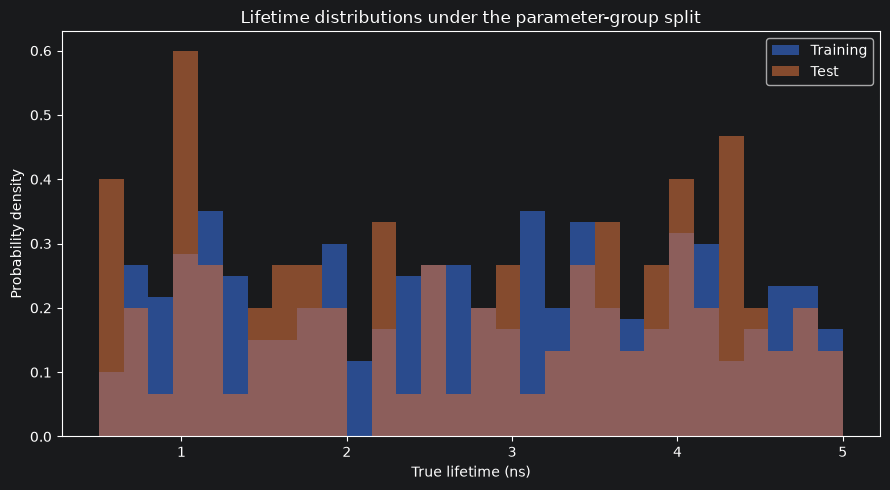

In [50]:
plt.figure(figsize=(9, 5))

plt.hist(
    y_train_grouped,
    bins=lifetime_bin_edges,
    density=True,
    alpha=0.6,
    label="Training",
)

plt.hist(
    y_test_grouped,
    bins=lifetime_bin_edges,
    density=True,
    alpha=0.6,
    label="Test",
)

plt.xlabel("True lifetime (ns)")
plt.ylabel("Probability density")
plt.title(
    "Lifetime distributions under the parameter-group split"
)
plt.legend()
plt.tight_layout()
plt.show()

### Distribution of unique group lifetimes

Every lifetime occurs once per parameter group but is repeated for each Poisson realization in the curve-level target arrays. To display the physical parameter distribution directly, one lifetime can be retained for each unique group.

In [51]:
train_group_lifetimes = (
    metadata_train_grouped
    .groupby("parameter_group")["lifetime_ns"]
    .first()
    .to_numpy()
)

test_group_lifetimes = (
    metadata_test_grouped
    .groupby("parameter_group")["lifetime_ns"]
    .first()
    .to_numpy()
)

In [52]:
assert train_group_lifetimes.size == 400
assert test_group_lifetimes.size == 100

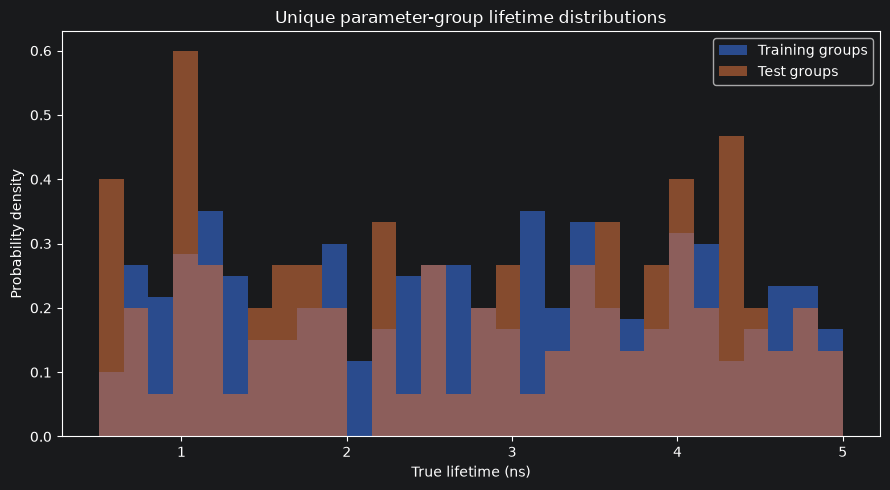

In [53]:
plt.figure(figsize=(9, 5))

plt.hist(
    train_group_lifetimes,
    bins=lifetime_bin_edges,
    density=True,
    alpha=0.6,
    label="Training groups",
)

plt.hist(
    test_group_lifetimes,
    bins=lifetime_bin_edges,
    density=True,
    alpha=0.6,
    label="Test groups",
)

plt.xlabel("True lifetime (ns)")
plt.ylabel("Probability density")
plt.title(
    "Unique parameter-group lifetime distributions"
)
plt.legend()
plt.tight_layout()
plt.show()

### Photon-count distributions under the grouped split

Although all realizations within one parameter group share the same expected curve, their measured total counts vary because of Poisson sampling.

The grouped split separates complete physical parameter sets. Consequently, differences in photon-count distributions can arise from both:

* different amplitudes, backgrounds, and lifetimes assigned to the selected
  groups;
* stochastic variation among Poisson realizations within those groups.

The present grouped experiment does not deliberately separate photon-count regimes. It only prevents shared parameter combinations across the split.

In [54]:
train_total_counts_grouped = (
    metadata_train_grouped[
        "measured_total_counts"
    ].to_numpy()
)

test_total_counts_grouped = (
    metadata_test_grouped[
        "measured_total_counts"
    ].to_numpy()
)

In [55]:
grouped_count_summary = pd.DataFrame(
    {
        "training": pd.Series(
            train_total_counts_grouped
        ).describe(),
        "test": pd.Series(
            test_total_counts_grouped
        ).describe(),
    }
)

grouped_count_summary

,training,test
count,2000.000000,500.000000
mean,287097.525000,312671.406000
std,211064.848227,215919.006998
min,12448.000000,28751.000000
25%,118293.750000,145887.250000
50%,220272.000000,263115.500000
75%,424373.500000,446179.250000
max,933951.000000,809886.000000


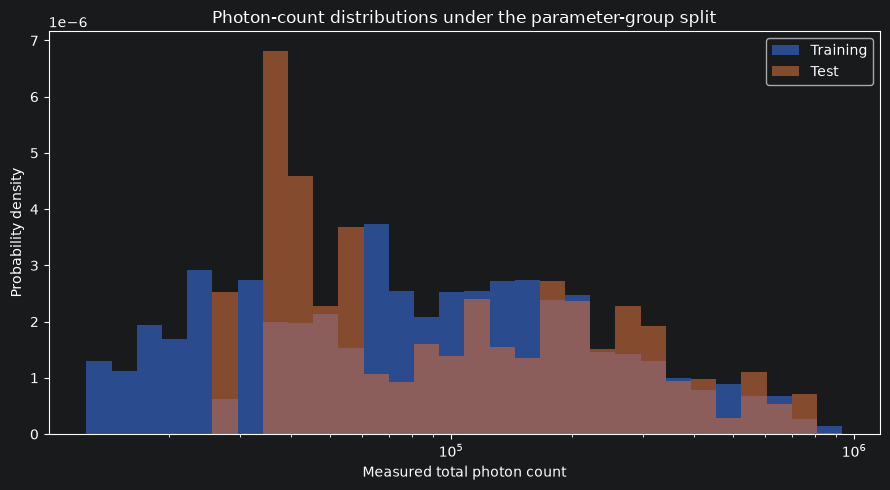

In [56]:
plt.figure(figsize=(9, 5))

plt.hist(
    train_total_counts_grouped,
    bins=count_bin_edges,
    density=True,
    alpha=0.6,
    label="Training",
)

plt.hist(
    test_total_counts_grouped,
    bins=count_bin_edges,
    density=True,
    alpha=0.6,
    label="Test",
)

plt.xscale("log")
plt.xlabel("Measured total photon count")
plt.ylabel("Probability density")
plt.title(
    "Photon-count distributions under the parameter-group split"
)
plt.legend()
plt.tight_layout()
plt.show()

### Comparison of subset sizes

The random and grouped protocols contain the same number of training and test curves. Therefore, later differences in model performance cannot be attributed simply to unequal sample counts.

The protocols differ in which relationships between observations are allowed across the split.

In [57]:
split_size_comparison = pd.DataFrame(
    {
        "protocol": [
            "Random row-level",
            "Parameter-group",
        ],
        "training_curves": [
            X_train_random.shape[0],
            X_train_grouped.shape[0],
        ],
        "test_curves": [
            X_test_random.shape[0],
            X_test_grouped.shape[0],
        ],
        "training_unique_groups": [
            n_train_groups_random,
            n_train_groups_grouped,
        ],
        "test_unique_groups": [
            n_test_groups_random,
            n_test_groups_grouped,
        ],
    }
)

split_size_comparison

,protocol,training_curves,test_curves,training_unique_groups,test_unique_groups
0,Random row-level,2000,500,500,329
1,Parameter-group,2000,500,400,100


### Interpretation of the parameter-group split

The group-aware procedure preserves the complete simulation hierarchy:

* every measured curve is assigned exactly once;
* every parameter group retains all of its Poisson realizations;
* approximately 80% of parameter groups are used for training;
* approximately 20% of parameter groups are reserved for testing;
* the training and test subsets remain within the same broad simulated
  lifetime and photon-count ranges.

Unlike the naive row-level split, this procedure does not allow an expected decay curve to contribute noisy realizations to both subsets.

The grouped protocol therefore asks a stronger question:

> How accurately can the model predict Poisson-sampled curves generated from
> parameter combinations that were not represented during training?

This remains an interpolation experiment because the held-out lifetimes, amplitudes, and backgrounds are sampled from the same overall parameter ranges as the training groups. It is not yet a test of extrapolation, unfamiliar noise regimes, model mismatch, or unfamiliar IRFs.

The next section verifies the defining property of the two protocols by measuring parameter-group overlap between their training and test subsets.

## 5. Verification of parameter-group overlap

A train–test split can be disjoint at the row level while still containing closely related observations in both subsets.

For the present dataset, two rows are related when they have the same `parameter_group`. Such curves share the same:

* lifetime;
* amplitude;
* background;
* time axis;
* expected mono-exponential decay.

They differ only through independent Poisson sampling.

This section converts the group-label arrays into sets and measures their intersection. The intersection contains parameter groups represented in both the training and test subsets.

For the naive row-level split, a non-empty intersection is expected because individual realizations were assigned independently. For the group-aware split, the intersection must be empty.

In [58]:
random_train_group_set = set(
    groups_train_random.tolist()
)

random_test_group_set = set(
    groups_test_random.tolist()
)

In [59]:
overlapping_groups_random = (
    random_train_group_set
    & random_test_group_set
)

In [60]:
n_overlapping_groups_random = len(
    overlapping_groups_random
)

print(
    "Random split training groups:",
    len(random_train_group_set),
)
print(
    "Random split test groups:",
    len(random_test_group_set),
)
print(
    "Groups represented in both subsets:",
    n_overlapping_groups_random,
)

Random split training groups: 500
Random split test groups: 329
Groups represented in both subsets: 329


In [61]:
random_test_group_overlap_fraction = (
    n_overlapping_groups_random
    / len(random_test_group_set)
)

random_train_group_overlap_fraction = (
    n_overlapping_groups_random
    / len(random_train_group_set)
)

print(
    "Fraction of test groups also present in training:",
    f"{random_test_group_overlap_fraction:.3f}",
)

print(
    "Fraction of training groups also present in test:",
    f"{random_train_group_overlap_fraction:.3f}",
)

Fraction of test groups also present in training: 1.000
Fraction of training groups also present in test: 0.658


In [62]:
random_train_only_groups = (
    random_train_group_set
    - random_test_group_set
)

random_test_only_groups = (
    random_test_group_set
    - random_train_group_set
)

print(
    "Groups found only in random training:",
    len(random_train_only_groups),
)

print(
    "Groups found only in random test:",
    len(random_test_only_groups),
)

print(
    "Groups shared across random training and test:",
    len(overlapping_groups_random),
)

Groups found only in random training: 171
Groups found only in random test: 0
Groups shared across random training and test: 329


In [63]:
assert random_train_only_groups.isdisjoint(
    random_test_only_groups
)

assert random_train_only_groups.isdisjoint(
    overlapping_groups_random
)

assert random_test_only_groups.isdisjoint(
    overlapping_groups_random
)

In [64]:
all_random_represented_groups = (
    random_train_only_groups
    | random_test_only_groups
    | overlapping_groups_random
)

all_parameter_group_set = set(
    np.arange(
        n_parameter_groups,
        dtype=np.int64,
    ).tolist()
)

assert (
    all_random_represented_groups
    == all_parameter_group_set
)

In [65]:
sorted_overlapping_groups_random = sorted(
    overlapping_groups_random
)

print(
    "First ten overlapping groups:",
    sorted_overlapping_groups_random[:10],
)

First ten overlapping groups: [5, 8, 9, 10, 11, 13, 14, 15, 16, 18]


In [66]:
example_overlapping_group = (
    sorted_overlapping_groups_random[0]
)

example_random_train_rows = (
    metadata_train_random.loc[
        metadata_train_random[
            "parameter_group"
        ] == example_overlapping_group
    ]
    .sort_values("realization_id")
)

example_random_test_rows = (
    metadata_test_random.loc[
        metadata_test_random[
            "parameter_group"
        ] == example_overlapping_group
    ]
    .sort_values("realization_id")
)

example_random_train_rows
example_random_test_rows

,curve_id,parameter_group,realization_id,lifetime_ns,amplitude,background,measured_total_counts
399,25,5,0,4.890301,8098.768902,3.929274,775803
286,29,5,4,4.890301,8098.768902,3.929274,775498


In [67]:
example_random_combined_rows = pd.concat(
    [
        example_random_train_rows,
        example_random_test_rows,
    ],
    ignore_index=True,
)

example_random_parameter_counts = (
    example_random_combined_rows[
        [
            "lifetime_ns",
            "amplitude",
            "background",
        ]
    ]
    .nunique()
)

example_random_parameter_counts

lifetime_ns    1
amplitude      1
background     1
dtype: int64

In [68]:
assert np.all(
    example_random_parameter_counts.to_numpy()
    == 1
)

In [69]:
random_train_realizations_per_group = (
    metadata_train_random
    .groupby("parameter_group")
    .size()
    .rename("training_realizations")
)

random_test_realizations_per_group = (
    metadata_test_random
    .groupby("parameter_group")
    .size()
    .rename("test_realizations")
)

random_group_assignment_table = pd.concat(
    [
        random_train_realizations_per_group,
        random_test_realizations_per_group,
    ],
    axis=1,
).fillna(0)

random_group_assignment_table = (
    random_group_assignment_table.astype(np.int64)
)

random_group_assignment_table.head(10)

,training_realizations,test_realizations
parameter_group,,
0,5,0
1,5,0
2,5,0
3,5,0
4,5,0
5,3,2
6,5,0
7,5,0
8,3,2


In [70]:
random_group_assignment_table[
    "total_realizations"
] = (
    random_group_assignment_table[
        "training_realizations"
    ]
    + random_group_assignment_table[
        "test_realizations"
    ]
)

assert np.all(
    random_group_assignment_table[
        "total_realizations"
    ].to_numpy()
    == n_realizations_per_group
)

In [71]:
random_assignment_patterns = (
    random_group_assignment_table
    .groupby(
        [
            "training_realizations",
            "test_realizations",
        ]
    )
    .size()
    .rename("number_of_groups")
    .reset_index()
    .sort_values(
        [
            "test_realizations",
            "training_realizations",
        ]
    )
)

random_assignment_patterns

,training_realizations,test_realizations,number_of_groups
4,5,0,171
3,4,1,193
2,3,2,104
1,2,3,29
0,1,4,3


### Distribution of realization assignments

The naive split can divide the five realizations of one parameter group in several ways. Examining these assignment patterns shows how frequently a test group is represented by one or more closely related training curves.

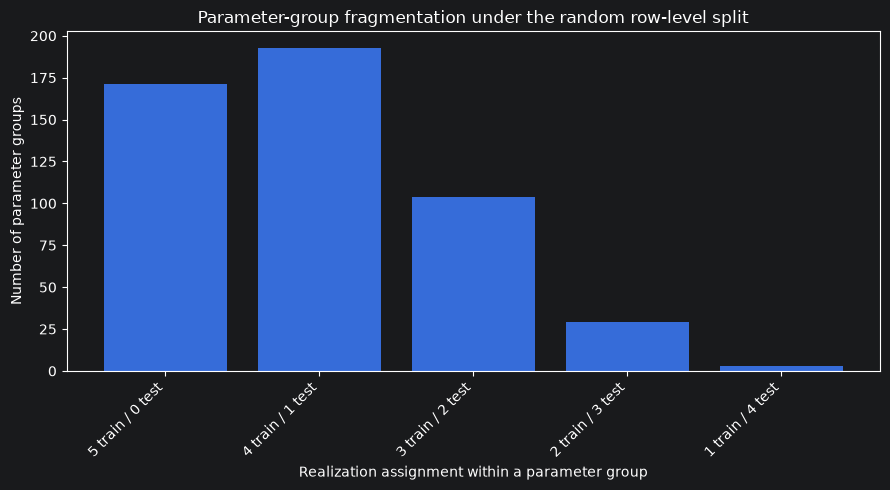

In [72]:
random_assignment_patterns[
    "assignment_label"
] = (
    random_assignment_patterns[
        "training_realizations"
    ].astype(str)
    + " train / "
    + random_assignment_patterns[
        "test_realizations"
    ].astype(str)
    + " test"
)

plt.figure(figsize=(9, 5))

plt.bar(
    random_assignment_patterns[
        "assignment_label"
    ],
    random_assignment_patterns[
        "number_of_groups"
    ],
)

plt.xlabel("Realization assignment within a parameter group")
plt.ylabel("Number of parameter groups")
plt.title(
    "Parameter-group fragmentation under the random row-level split"
)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Interpretation

A bar such as:

```
4 train / 1 test
```

means that for those groups, the model receives four Poisson realizations during training and is evaluated on the fifth realization. That is a much easier test than predicting an entirely unfamiliar parameter combination.

## Now we repeat the overlap calculation for the group-aware protocol

In [73]:
grouped_train_group_set = set(
    groups_train_grouped.tolist()
)

grouped_test_group_set = set(
    groups_test_grouped.tolist()
)

In [74]:
assert (
    len(grouped_train_group_set)
    == n_train_groups_grouped
)

assert (
    len(grouped_test_group_set)
    == n_test_groups_grouped
)

In [75]:
overlapping_groups_grouped = (
    grouped_train_group_set
    & grouped_test_group_set
)

n_overlapping_groups_grouped = len(
    overlapping_groups_grouped
)

print(
    "Grouped split training groups:",
    len(grouped_train_group_set),
)
print(
    "Grouped split test groups:",
    len(grouped_test_group_set),
)
print(
    "Groups represented in both subsets:",
    n_overlapping_groups_grouped,
)

Grouped split training groups: 400
Grouped split test groups: 100
Groups represented in both subsets: 0


In [76]:
assert n_overlapping_groups_grouped == 0

assert grouped_train_group_set.isdisjoint(
    grouped_test_group_set
)

In [77]:
all_grouped_represented_groups = (
    grouped_train_group_set
    | grouped_test_group_set
)

assert (
    all_grouped_represented_groups
    == all_parameter_group_set
)

assert (
    len(grouped_train_group_set)
    + len(grouped_test_group_set)
    == n_parameter_groups
)

In [78]:
assert np.all(
    metadata_train_grouped
    .groupby("parameter_group")
    .size()
    .to_numpy()
    == n_realizations_per_group
)

assert np.all(
    metadata_test_grouped
    .groupby("parameter_group")
    .size()
    .to_numpy()
    == n_realizations_per_group
)

### Direct comparison of group overlap

The two splitting protocols contain equal numbers of curves but differ strongly in group independence. The table below compares the number and fraction of shared parameter groups.

In [79]:
grouped_test_group_overlap_fraction = (
    n_overlapping_groups_grouped
    / len(grouped_test_group_set)
)

overlap_comparison = pd.DataFrame(
    {
        "protocol": [
            "Random row-level",
            "Parameter-group",
        ],
        "training_unique_groups": [
            len(random_train_group_set),
            len(grouped_train_group_set),
        ],
        "test_unique_groups": [
            len(random_test_group_set),
            len(grouped_test_group_set),
        ],
        "overlapping_groups": [
            n_overlapping_groups_random,
            n_overlapping_groups_grouped,
        ],
        "test_groups_also_in_training_fraction": [
            random_test_group_overlap_fraction,
            grouped_test_group_overlap_fraction,
        ],
    }
)

overlap_comparison

,protocol,training_unique_groups,test_unique_groups,overlapping_groups,test_groups_also_in_training_fraction
0,Random row-level,500,329,329,1.0
1,Parameter-group,400,100,0,0.0


In [80]:
overlap_comparison_display = (
    overlap_comparison.copy()
)

overlap_comparison_display[
    "test_groups_also_in_training_fraction"
] = (
    overlap_comparison_display[
        "test_groups_also_in_training_fraction"
    ].round(3)
)

overlap_comparison_display

,protocol,training_unique_groups,test_unique_groups,overlapping_groups,test_groups_also_in_training_fraction
0,Random row-level,500,329,329,1.0
1,Parameter-group,400,100,0,0.0


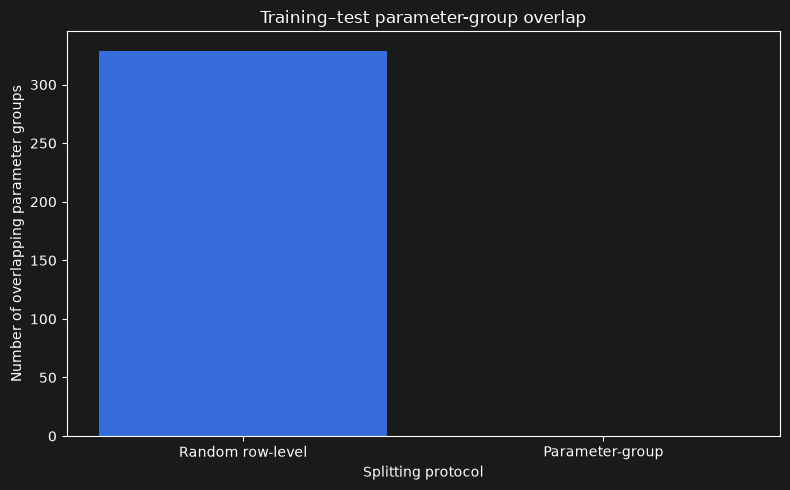

In [81]:
plt.figure(figsize=(8, 5))

plt.bar(
    overlap_comparison["protocol"],
    overlap_comparison["overlapping_groups"],
)

plt.xlabel("Splitting protocol")
plt.ylabel("Number of overlapping parameter groups")
plt.title(
    "Training–test parameter-group overlap"
)
plt.tight_layout()
plt.show()

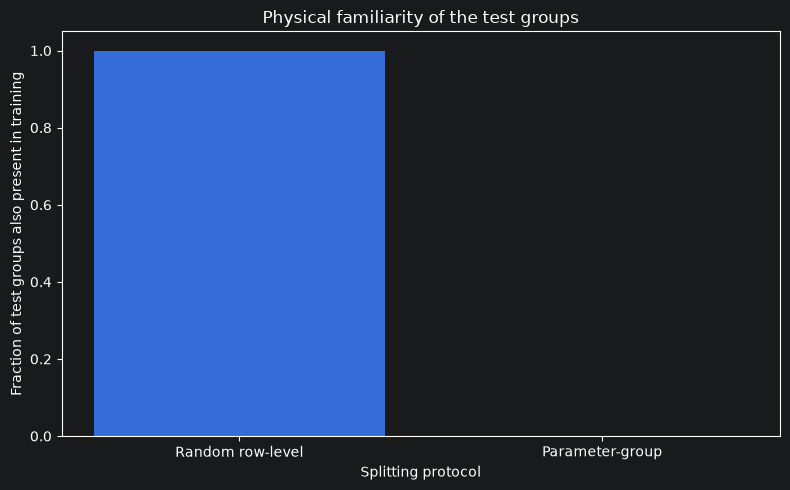

In [82]:
plt.figure(figsize=(8, 5))

plt.bar(
    overlap_comparison["protocol"],
    overlap_comparison[
        "test_groups_also_in_training_fraction"
    ],
)

plt.xlabel("Splitting protocol")
plt.ylabel(
    "Fraction of test groups also present in training"
)
plt.title(
    "Physical familiarity of the test groups"
)
plt.ylim(0.0, 1.05)
plt.tight_layout()
plt.show()

### Row-level disjointness versus group-level disjointness

Both protocols satisfy row-level disjointness:

$$
I_{\mathrm{train}}
\cap
I_{\mathrm{test}}
=
\varnothing,
$$

where $I$ denotes the set of curve indices.

Only the parameter-group split also satisfies group-level disjointness:

$$
G_{\mathrm{train}}
\cap
G_{\mathrm{test}}
=
\varnothing,
$$

where $G$ denotes the set of underlying simulation parameter groups.

The naive split is therefore not incorrect because it duplicates rows. It is problematic because it separates statistically related realizations and then treats them as independent training and test observations.

In [83]:
split_verification = pd.DataFrame(
    {
        "protocol": [
            "Random row-level",
            "Parameter-group",
        ],
        "row_overlap": [
            np.intersect1d(
                random_train_indices,
                random_test_indices,
            ).size,
            np.intersect1d(
                grouped_train_indices,
                grouped_test_indices,
            ).size,
        ],
        "group_overlap": [
            n_overlapping_groups_random,
            n_overlapping_groups_grouped,
        ],
        "all_rows_assigned": [
            (
                random_train_indices.size
                + random_test_indices.size
                == n_curves
            ),
            (
                grouped_train_indices.size
                + grouped_test_indices.size
                == n_curves
            ),
        ],
        "all_groups_assigned": [
            (
                random_train_group_set
                | random_test_group_set
                == all_parameter_group_set
            ),
            (
                grouped_train_group_set
                | grouped_test_group_set
                == all_parameter_group_set
            ),
        ],
    }
)

split_verification

,protocol,row_overlap,group_overlap,all_rows_assigned,all_groups_assigned
0,Random row-level,0,329,True,True
1,Parameter-group,0,0,True,True


In [84]:
assert split_verification[
    "row_overlap"
].eq(0).all()

assert split_verification[
    "all_rows_assigned"
].all()

assert split_verification[
    "all_groups_assigned"
].all()

assert n_overlapping_groups_random > 0
assert n_overlapping_groups_grouped == 0

### Expected random-split assignment patterns

If each realization were assigned independently to testing with probability $p=0.2$, the number of test realizations from a five-realization group would approximately follow a binomial distribution:

$$
K \sim \operatorname{Binomial}(n=5,p=0.2).
$$

The actual `train_test_split` assignment selects an exact total number of test rows without replacement, so the group counts are not perfectly independent. The binomial model is used only as an intuitive reference.

In [85]:
test_realization_counts = np.arange(
    n_realizations_per_group + 1,
    dtype=np.int64,
)

approximate_pattern_probabilities = np.array(
    [
        comb(
            n_realizations_per_group,
            int(n_test_realizations),
        )
        * group_test_size ** n_test_realizations
        * (
            1.0 - group_test_size
        ) ** (
            n_realizations_per_group
            - n_test_realizations
        )
        for n_test_realizations
        in test_realization_counts
    ],
    dtype=np.float64,
)

approximate_expected_group_counts = (
    n_parameter_groups
    * approximate_pattern_probabilities
)

In [86]:
approximate_assignment_table = pd.DataFrame(
    {
        "training_realizations": (
            n_realizations_per_group
            - test_realization_counts
        ),
        "test_realizations": test_realization_counts,
        "approximate_probability": (
            approximate_pattern_probabilities
        ),
        "approximate_expected_groups": (
            approximate_expected_group_counts
        ),
    }
)

approximate_assignment_table

,training_realizations,test_realizations,approximate_probability,approximate_expected_groups
0,5,0,0.32768,163.84
1,4,1,0.40960,204.80
2,3,2,0.20480,102.40
3,2,3,0.05120,25.60
4,1,4,0.00640,3.20
5,0,5,0.00032,0.16


### Interpretation of group-overlap verification

The two splitting protocols are both valid partitions of the curve rows, but they represent different scientific experiments.

Under the naive row-level split:

* no exact histogram is duplicated across training and testing;
* many parameter groups are represented in both subsets;
* nearly every test group is likely to have related realizations in training;
* the test score primarily measures prediction of new noise realizations from
  familiar expected decay curves.

Under the parameter-group split:

* no exact histogram is duplicated across training and testing;
* the parameter-group intersection is empty;
* all realizations from one expected decay remain together;
* every test curve comes from a parameter combination absent from training.

The parameter-group split therefore provides the more defensible estimate of interpolation performance for unfamiliar parameter combinations within the same simulated physical ranges.

This does not imply that the random-split result is useless. It answers a narrower question about prediction under repeated sampling of familiar simulation conditions. The problem arises only when that score is interpreted as evidence of broader generalization.

The next section trains identical regression models under both protocols. Any difference in performance can then be attributed to the splitting strategy rather than to different model definitions or different numbers of training and test curves.

## 6. Model training under both protocols

The random and parameter-group splits contain the same numbers of training and test curves, and both use the same normalized histogram features.

The only intended difference is the independence of the underlying simulation parameter groups:

* under the random row-level split, many test groups also appear in training;
* under the parameter-group split, all test groups are absent from training.

To isolate the effect of this difference, identical regression models and hyperparameters will be used under both protocols.

Four baselines are considered:

1. a mean-prediction baseline;
2. Ridge regression;
3. Random Forest regression;
4. Gradient Boosting regression.

The mean baseline does not use the histogram features. It predicts the mean training lifetime for every test curve. The remaining models learn a mapping from the normalized histogram bins to the fluorescence lifetime.

### Why identical models must be used

The experimental logic is:

```
random protocol:
model definition + random training data → random-protocol predictions

grouped protocol:
same model definition + grouped training data → grouped-protocol predictions
```

There should be no change, for example, of Ridge(`alpha=1.0`) for one split and Ridge(`alpha=0.1`) for another; the number of trees; the random state; feature normalization; training-set size. Otherwise, a performance difference could be caused by the model configuration rather than the split.

Model performance will be compared in the next section. The purpose of the present section is to define, fit, and verify the models and their predictions.

### Model definitions

The model configurations are defined once and treated as reusable templates.

Before training under each protocol, `sklearn.base.clone` creates a fresh, unfitted estimator with the same hyperparameters. This prevents the fitted state from one protocol from being reused accidentally in the other protocol.

In [87]:
model_random_state = 42

model_templates = {
    "Ridge": Ridge(
        alpha=1.0,
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=model_random_state,
        n_jobs=-1,
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=model_random_state,
    ),
}

In [88]:
for model_name, model_template in model_templates.items():
    print(f"{model_name}:")
    print(model_template)
    print()

Ridge:
Ridge()

Random Forest:
RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)

Gradient Boosting:
GradientBoostingRegressor(random_state=42)



### Mean-prediction baseline

The mean baseline predicts the average lifetime of the relevant training set for every test observation.

Although this model is intentionally simple, it provides an essential reference. A learned regression model is useful only if it performs meaningfully better than predicting one constant value for all curves.

In [89]:
def predict_training_mean(
    y_train: np.ndarray,
    n_predictions: int,
) -> np.ndarray:
    """Predict the mean training target for every requested sample."""
    if y_train.ndim != 1:
        raise ValueError("y_train must be one-dimensional.")

    if y_train.size == 0:
        raise ValueError("y_train must not be empty.")

    if n_predictions < 0:
        raise ValueError("n_predictions must be non-negative.")

    training_mean = float(np.mean(y_train))

    return np.full(
        shape=n_predictions,
        fill_value=training_mean,
        dtype=np.float64,
    )

In [90]:
mean_prediction_random = predict_training_mean(
    y_train=y_train_random,
    n_predictions=y_test_random.size,
)

mean_prediction_grouped = predict_training_mean(
    y_train=y_train_grouped,
    n_predictions=y_test_grouped.size,
)

mean_prediction_random.shape
# (500,)

mean_prediction_grouped.shape
# (500,)

(500,)

In [91]:
print(
    "Random-split training mean lifetime:",
    f"{y_train_random.mean():.4f} ns",
)

print(
    "Grouped-split training mean lifetime:",
    f"{y_train_grouped.mean():.4f} ns",
)

print(
    "First random-split baseline prediction:",
    f"{mean_prediction_random[0]:.4f} ns",
)

print(
    "First grouped-split baseline prediction:",
    f"{mean_prediction_grouped[0]:.4f} ns",
)

Random-split training mean lifetime: 2.7400 ns
Grouped-split training mean lifetime: 2.7375 ns
First random-split baseline prediction: 2.7400 ns
First grouped-split baseline prediction: 2.7375 ns


In [92]:
assert np.allclose(
    mean_prediction_random,
    y_train_random.mean(),
)

assert np.allclose(
    mean_prediction_grouped,
    y_train_grouped.mean(),
)

### Reusable training procedure

The same training function will be applied to both evaluation protocols.

For each model template, the function:

1. creates a fresh estimator using `clone`;
2. fits the estimator using only the supplied training subset;
3. predicts lifetimes for the supplied test subset;
4. stores the fitted model and prediction array.

Using one shared function reduces duplicated code and helps ensure that the random and grouped experiments follow identical training procedures.

In [93]:
def fit_and_predict_models(
    model_templates: dict[str, object],
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test: np.ndarray,
) -> tuple[
    dict[str, object],
    dict[str, np.ndarray],
]:
    """Fit fresh model clones and predict the test targets."""
    if X_train.ndim != 2:
        raise ValueError("X_train must be two-dimensional.")

    if X_test.ndim != 2:
        raise ValueError("X_test must be two-dimensional.")

    if y_train.ndim != 1:
        raise ValueError("y_train must be one-dimensional.")

    if X_train.shape[0] != y_train.shape[0]:
        raise ValueError(
            "X_train and y_train must contain the same "
            "number of samples."
        )

    if X_train.shape[1] != X_test.shape[1]:
        raise ValueError(
            "X_train and X_test must contain the same "
            "number of features."
        )

    fitted_models: dict[str, object] = {}
    predictions: dict[str, np.ndarray] = {}

    for model_name, model_template in model_templates.items():
        model = clone(model_template)

        model.fit(
            X_train,
            y_train,
        )

        model_predictions = model.predict(X_test)

        fitted_models[model_name] = model
        predictions[model_name] = np.asarray(
            model_predictions,
            dtype=np.float64,
        )

    return fitted_models, predictions

In [94]:
(
    fitted_models_random,
    predictions_random,
) = fit_and_predict_models(
    model_templates=model_templates,
    X_train=X_train_random,
    y_train=y_train_random,
    X_test=X_test_random,
)

In [95]:
predictions_random = {
    "Mean baseline": mean_prediction_random,
    **predictions_random,
}

In [96]:
(
    fitted_models_grouped,
    predictions_grouped,
) = fit_and_predict_models(
    model_templates=model_templates,
    X_train=X_train_grouped,
    y_train=y_train_grouped,
    X_test=X_test_grouped,
)

In [97]:
predictions_grouped = {
    "Mean baseline": mean_prediction_grouped,
    **predictions_grouped,
}

In [98]:
expected_model_names = [
    "Mean baseline",
    "Ridge",
    "Random Forest",
    "Gradient Boosting",
]

assert list(predictions_random.keys()) == expected_model_names
assert list(predictions_grouped.keys()) == expected_model_names

assert list(fitted_models_random.keys()) == expected_model_names[1:]
assert list(fitted_models_grouped.keys()) == expected_model_names[1:]

In [99]:
for model_name in expected_model_names:
    assert predictions_random[
        model_name
    ].shape == y_test_random.shape

    assert predictions_grouped[
        model_name
    ].shape == y_test_grouped.shape

In [100]:
for model_name in expected_model_names:
    assert np.all(
        np.isfinite(
            predictions_random[model_name]
        )
    )

    assert np.all(
        np.isfinite(
            predictions_grouped[model_name]
        )
    )

In [101]:
for model_name in expected_model_names:
    assert predictions_random[model_name].ndim == 1
    assert predictions_grouped[model_name].ndim == 1

In [102]:
for model_name in model_templates:
    assert (
        fitted_models_random[model_name]
        is not fitted_models_grouped[model_name]
    )

    assert (
        fitted_models_random[model_name]
        is not model_templates[model_name]
    )

    assert (
        fitted_models_grouped[model_name]
        is not model_templates[model_name]
    )

In [103]:
assert not hasattr(
    model_templates["Ridge"],
    "coef_",
)

assert hasattr(
    fitted_models_random["Ridge"],
    "coef_",
)

assert hasattr(
    fitted_models_grouped["Ridge"],
    "coef_",
)

### Prediction sanity checks

Before calculating formal error metrics, the prediction distributions are inspected for obvious numerical problems.

The models are not explicitly constrained to predict lifetimes within the simulation interval. In particular, a linear model such as Ridge may theoretically produce values below or above the training range.

Such predictions should not be clipped automatically. Clipping would change the model output and could artificially improve evaluation metrics. Instead, the unmodified prediction ranges are reported.

In [104]:
prediction_range_rows = []

for protocol_name, predictions in [
    ("Random row-level", predictions_random),
    ("Parameter-group", predictions_grouped),
]:
    for model_name, model_predictions in predictions.items():
        prediction_range_rows.append(
            {
                "protocol": protocol_name,
                "model": model_name,
                "minimum_prediction_ns": (
                    model_predictions.min()
                ),
                "maximum_prediction_ns": (
                    model_predictions.max()
                ),
                "mean_prediction_ns": (
                    model_predictions.mean()
                ),
                "standard_deviation_ns": (
                    model_predictions.std()
                ),
            }
        )

prediction_range_table = pd.DataFrame(
    prediction_range_rows
)

prediction_range_table

,protocol,model,minimum_prediction_ns,maximum_prediction_ns,mean_prediction_ns,standard_deviation_ns
0,Random row-level,Mean baseline,2.740038,2.740038,2.740038,4.440892e-16
1,Random row-level,Ridge,0.182091,3.726648,2.690410,9.472299e-01
2,Random row-level,Random Forest,0.536629,4.941512,2.695563,1.311865e+00
3,Random row-level,Gradient Boosting,0.550201,4.959194,2.691844,1.312469e+00
4,Parameter-group,Mean baseline,2.737453,2.737453,2.737453,4.440892e-16
5,Parameter-group,Ridge,0.192461,3.720994,2.646775,1.025129e+00
6,Parameter-group,Random Forest,0.543937,4.935186,2.706110,1.360880e+00
7,Parameter-group,Gradient Boosting,0.552021,4.951547,2.706065,1.360687e+00


In [105]:
prediction_bound_rows = []

for protocol_name, predictions in [
    ("Random row-level", predictions_random),
    ("Parameter-group", predictions_grouped),
]:
    for model_name, model_predictions in predictions.items():
        below_range = (
            model_predictions
            < lifetime_range_ns[0]
        )

        above_range = (
            model_predictions
            > lifetime_range_ns[1]
        )

        prediction_bound_rows.append(
            {
                "protocol": protocol_name,
                "model": model_name,
                "predictions_below_range": int(
                    below_range.sum()
                ),
                "predictions_above_range": int(
                    above_range.sum()
                ),
                "predictions_outside_range": int(
                    (below_range | above_range).sum()
                ),
            }
        )

prediction_bound_table = pd.DataFrame(
    prediction_bound_rows
)

prediction_bound_table

,protocol,model,predictions_below_range,predictions_above_range,predictions_outside_range
0,Random row-level,Mean baseline,0,0,0
1,Random row-level,Ridge,10,0,10
2,Random row-level,Random Forest,0,0,0
3,Random row-level,Gradient Boosting,0,0,0
4,Parameter-group,Mean baseline,0,0,0
5,Parameter-group,Ridge,30,0,30
6,Parameter-group,Random Forest,0,0,0
7,Parameter-group,Gradient Boosting,0,0,0


In [106]:
random_prediction_preview = pd.DataFrame(
    {
        "true_lifetime_ns": y_test_random[:10],
        **{
            model_name: model_predictions[:10]
            for model_name, model_predictions
            in predictions_random.items()
        },
    }
)

random_prediction_preview

,true_lifetime_ns,Mean baseline,Ridge,Random Forest,Gradient Boosting
0,0.957524,2.740038,1.215320,0.954974,0.964666
1,3.482889,2.740038,3.409253,3.647197,3.567381
2,1.398990,2.740038,1.913549,1.385147,1.367904
3,2.563523,2.740038,2.952248,2.564422,2.533373
4,3.378035,2.740038,3.342422,3.423265,3.429986
5,2.060914,2.740038,2.626853,2.012418,2.046702
6,2.207588,2.740038,2.726922,2.190966,2.178397
7,2.339524,2.740038,2.814182,2.337446,2.353185
8,4.828539,2.740038,3.694939,4.825238,4.853128
9,2.441382,2.740038,2.892070,2.433348,2.453234


In [107]:
grouped_prediction_preview = pd.DataFrame(
    {
        "true_lifetime_ns": y_test_grouped[:10],
        **{
            model_name: model_predictions[:10]
            for model_name, model_predictions
            in predictions_grouped.items()
        },
    }
)

grouped_prediction_preview

,true_lifetime_ns,Mean baseline,Ridge,Random Forest,Gradient Boosting
0,3.982802,2.737453,3.506524,4.007118,3.968467
1,3.982802,2.737453,3.504219,3.973892,3.956532
2,3.982802,2.737453,3.500298,3.972081,3.963290
3,3.982802,2.737453,3.505470,3.993275,3.960896
4,3.982802,2.737453,3.496909,3.961446,3.986231
5,4.363691,2.737453,3.594879,4.317351,4.395792
6,4.363691,2.737453,3.591664,4.337030,4.422780
7,4.363691,2.737453,3.591044,4.395947,4.393145
8,4.363691,2.737453,3.598599,4.359866,4.395425
9,4.363691,2.737453,3.594039,4.343696,4.259112


### Preliminary prediction visualization

The following scatter plots provide a qualitative check of the predictions. They are not a substitute for numerical metrics.

A perfect regressor would place every point on the diagonal line

$$
\hat{\tau}=\tau.
$$

Systematic deviations from the diagonal may reveal bias, compression of the prediction range, or poor performance near the lifetime boundaries.

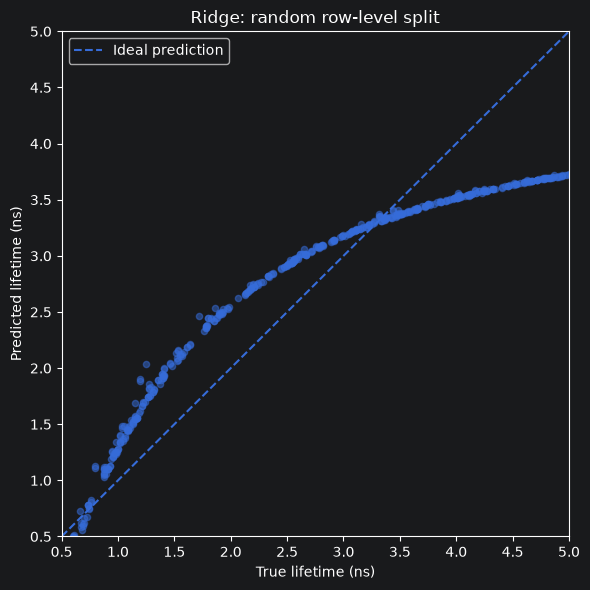

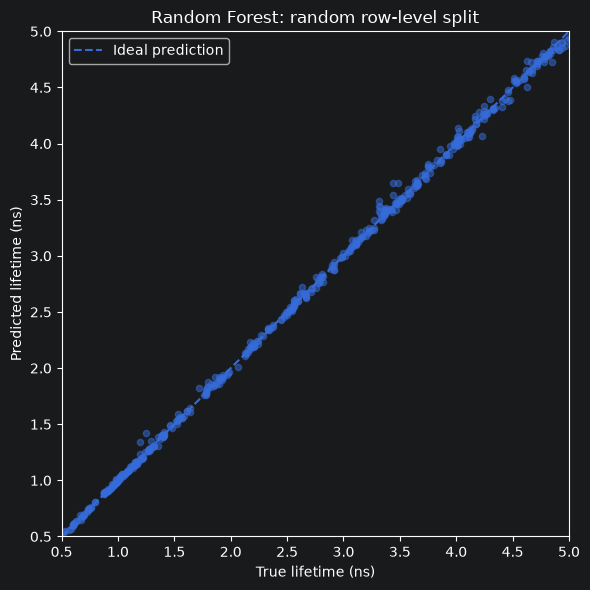

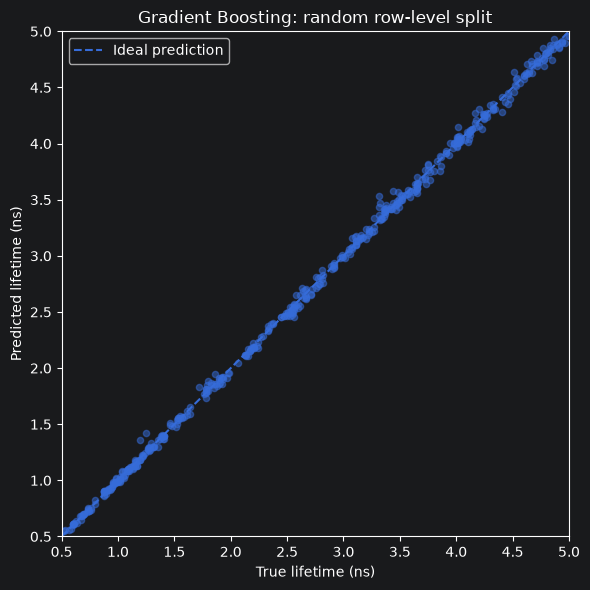

In [108]:
for model_name in [
    "Ridge",
    "Random Forest",
    "Gradient Boosting",
]:
    plt.figure(figsize=(6, 6))

    plt.scatter(
        y_test_random,
        predictions_random[model_name],
        alpha=0.5,
        s=20,
    )

    plt.plot(
        lifetime_range_ns,
        lifetime_range_ns,
        linestyle="--",
        label="Ideal prediction",
    )

    plt.xlabel("True lifetime (ns)")
    plt.ylabel("Predicted lifetime (ns)")
    plt.title(
        f"{model_name}: random row-level split"
    )
    plt.xlim(lifetime_range_ns)
    plt.ylim(lifetime_range_ns)
    plt.legend()
    plt.tight_layout()
    plt.show()

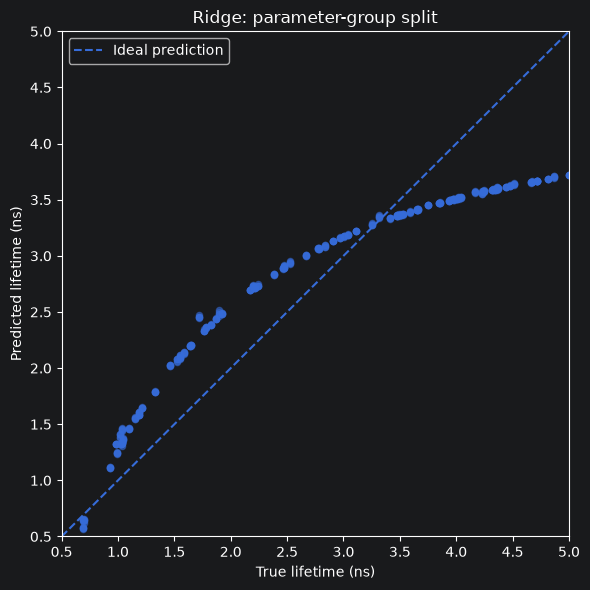

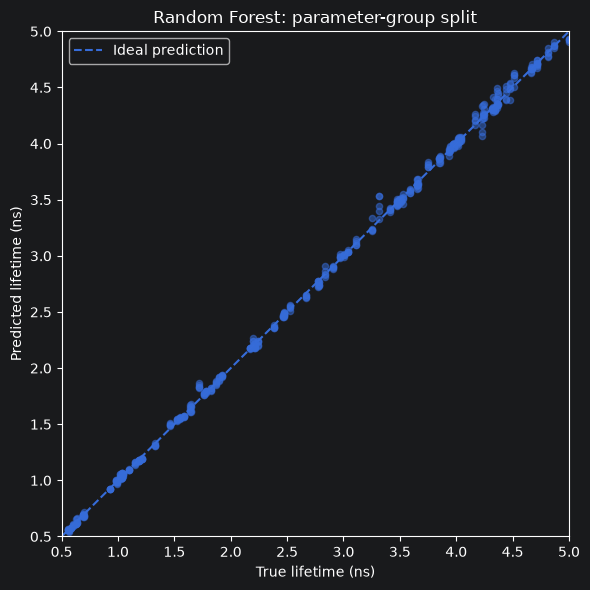

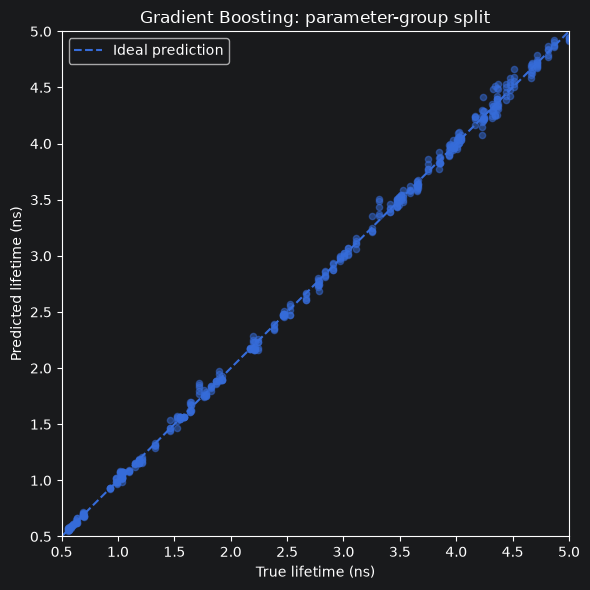

In [109]:
for model_name in [
    "Ridge",
    "Random Forest",
    "Gradient Boosting",
]:
    plt.figure(figsize=(6, 6))

    plt.scatter(
        y_test_grouped,
        predictions_grouped[model_name],
        alpha=0.5,
        s=20,
    )

    plt.plot(
        lifetime_range_ns,
        lifetime_range_ns,
        linestyle="--",
        label="Ideal prediction",
    )

    plt.xlabel("True lifetime (ns)")
    plt.ylabel("Predicted lifetime (ns)")
    plt.title(
        f"{model_name}: parameter-group split"
    )
    plt.xlim(lifetime_range_ns)
    plt.ylim(lifetime_range_ns)
    plt.legend()
    plt.tight_layout()
    plt.show()

### Interpretation of model training

Identical model templates have now been trained under both splitting protocols.

For each protocol:

* the mean baseline uses only the corresponding training-target mean;
* Ridge learns a regularized linear relationship between normalized histogram bins and lifetime;
* Random Forest learns a nonlinear ensemble of regression trees;
* Gradient Boosting sequentially builds trees that correct previous residual errors;
* every model generates one finite lifetime prediction per test curve.

Fresh estimator clones were used for each protocol, so the fitted state from one experiment cannot influence the other.

The two prediction collections differ only because the models were trained and tested using different row assignments:

```text
predictions_random
predictions_grouped
```

The random protocol allows physically familiar parameter groups across the training–test boundary, whereas the grouped protocol evaluates completely held-out parameter combinations.

The next section calculates identical error metrics for both prediction collections and determines how strongly the apparent model performance depends on the splitting strategy.

## 7. Comparison of test metrics

The same four regression models have been trained under two evaluation protocols:

* a random ("naive") row-level split containing substantial parameter-group overlap;
* a parameter-group split with no parameter-group overlap.

This section evaluates the resulting test predictions using identical metrics. The following quantities are reported:

* mean absolute error;
* median absolute error;
* mean absolute relative error;
* median absolute relative error;
* coefficient of determination, $R^2$.

Absolute errors are reported in nanoseconds. Relative errors are reported as percentages.

A model is considered better when it has:

* lower absolute and relative errors;
* higher $R^2$.

The mean-prediction baseline provides a reference for determining whether the learned models extract useful lifetime information from the histogram shapes.

### Error definitions

For a true lifetime ($\tau_i$) and predicted lifetime ($\hat{\tau}_i$), the absolute error is

$$
e_i
=
\left|
\hat{\tau}_i-\tau_i
\right|.
$$

The absolute relative error is

$$
e_{i,\mathrm{rel}}
=
\frac{
\left|\hat{\tau}_i-\tau_i\right|
}{
\tau_i
}.
$$

Multiplying the relative error by $100$ expresses it as a percentage:

$$
e_{i,\mathrm{rel},\%}
=
100
\frac{
\left|\hat{\tau}_i-\tau_i\right|
}{
\tau_i
}.
$$

Because all simulated lifetimes are strictly positive, the denominator is nonzero for every sample.

### Relative-error calculation

A dedicated helper function is used to calculate one absolute relative error for each prediction.

The function validates that the true and predicted arrays are one-dimensional, have equal shapes, contain finite values, and have strictly positive true targets.

In [110]:
def absolute_relative_errors(
    y_true: np.ndarray,
    y_pred: np.ndarray,
) -> np.ndarray:
    """Calculate absolute relative errors for positive targets."""
    if y_true.ndim != 1:
        raise ValueError("y_true must be one-dimensional.")

    if y_pred.ndim != 1:
        raise ValueError("y_pred must be one-dimensional.")

    if y_true.shape != y_pred.shape:
        raise ValueError(
            "y_true and y_pred must have the same shape."
        )

    if not np.all(np.isfinite(y_true)):
        raise ValueError("y_true must contain only finite values.")

    if not np.all(np.isfinite(y_pred)):
        raise ValueError("y_pred must contain only finite values.")

    if np.any(y_true <= 0):
        raise ValueError(
            "Relative errors require strictly positive targets."
        )

    return np.abs(y_pred - y_true) / y_true

In [111]:
example_y_true = np.array(
    [1.0, 2.0, 4.0],
    dtype=np.float64,
)

example_y_pred = np.array(
    [1.1, 1.8, 4.4],
    dtype=np.float64,
)

example_relative_errors = absolute_relative_errors(
    y_true=example_y_true,
    y_pred=example_y_pred,
)

example_relative_errors

array([0.1, 0.1, 0.1])

In [112]:
assert np.allclose(
    example_relative_errors,
    np.array([0.1, 0.1, 0.1]),
)

### Evaluation of one prediction array

The following helper calculates all selected metrics for one set of true and predicted lifetimes.

Returning the metrics in a dictionary makes it easy to combine results from several models and protocols into a pandas DataFrame.

In [113]:
def evaluate_predictions(
    y_true: np.ndarray,
    y_pred: np.ndarray,
) -> dict[str, float]:
    """Calculate regression metrics for one prediction array."""
    relative_errors = absolute_relative_errors(
        y_true=y_true,
        y_pred=y_pred,
    )

    return {
        "mae_ns": float(
            mean_absolute_error(
                y_true,
                y_pred,
            )
        ),
        "median_absolute_error_ns": float(
            median_absolute_error(
                y_true,
                y_pred,
            )
        ),
        "mean_absolute_relative_error_percent": float(
            100.0 * np.mean(relative_errors)
        ),
        "median_absolute_relative_error_percent": float(
            100.0 * np.median(relative_errors)
        ),
        "r2": float(
            r2_score(
                y_true,
                y_pred,
            )
        ),
    }

### Evaluation of a complete prediction dictionary

A second helper applies the metric function to every model in a prediction dictionary.

The protocol name is included in every result row so that outputs from the random and grouped experiments can later be concatenated.

In [114]:
def evaluate_prediction_collection(
    protocol_name: str,
    y_true: np.ndarray,
    predictions: dict[str, np.ndarray],
) -> pd.DataFrame:
    """Evaluate all model predictions for one protocol."""
    result_rows: list[dict[str, object]] = []

    for model_name, model_predictions in predictions.items():
        metrics = evaluate_predictions(
            y_true=y_true,
            y_pred=model_predictions,
        )

        result_rows.append(
            {
                "protocol": protocol_name,
                "model": model_name,
                **metrics,
            }
        )

    return pd.DataFrame(result_rows)

In [115]:
random_metric_results = evaluate_prediction_collection(
    protocol_name="Random row-level",
    y_true=y_test_random,
    predictions=predictions_random,
)

random_metric_results

,protocol,model,mae_ns,median_absolute_error_ns,mean_absolute_relative_error_percent,median_absolute_relative_error_percent,r2
0,Random row-level,Mean baseline,1.151632,1.244408,70.740285,35.653954,-0.001298
1,Random row-level,Ridge,0.440765,0.417662,19.711572,18.253512,0.839982
2,Random row-level,Random Forest,0.022035,0.012704,0.880952,0.577919,0.999266
3,Random row-level,Gradient Boosting,0.027132,0.018108,1.167676,0.800240,0.999106


In [116]:
grouped_metric_results = evaluate_prediction_collection(
    protocol_name="Parameter-group",
    y_true=y_test_grouped,
    predictions=predictions_grouped,
)

grouped_metric_results

,protocol,model,mae_ns,median_absolute_error_ns,mean_absolute_relative_error_percent,median_absolute_relative_error_percent,r2
0,Parameter-group,Mean baseline,1.215243,1.241192,78.596542,37.234271,-0.000642
1,Parameter-group,Ridge,0.458656,0.438607,20.920816,18.719343,0.847796
2,Parameter-group,Random Forest,0.022911,0.014879,0.969337,0.669203,0.999298
3,Parameter-group,Gradient Boosting,0.029933,0.022664,1.268709,0.874397,0.999030


In [117]:
metric_results = pd.concat(
    [
        random_metric_results,
        grouped_metric_results,
    ],
    ignore_index=True,
)

metric_results

,protocol,model,mae_ns,median_absolute_error_ns,mean_absolute_relative_error_percent,median_absolute_relative_error_percent,r2
0,Random row-level,Mean baseline,1.151632,1.244408,70.740285,35.653954,-0.001298
1,Random row-level,Ridge,0.440765,0.417662,19.711572,18.253512,0.839982
2,Random row-level,Random Forest,0.022035,0.012704,0.880952,0.577919,0.999266
3,Random row-level,Gradient Boosting,0.027132,0.018108,1.167676,0.800240,0.999106
4,Parameter-group,Mean baseline,1.215243,1.241192,78.596542,37.234271,-0.000642
5,Parameter-group,Ridge,0.458656,0.438607,20.920816,18.719343,0.847796
6,Parameter-group,Random Forest,0.022911,0.014879,0.969337,0.669203,0.999298
7,Parameter-group,Gradient Boosting,0.029933,0.022664,1.268709,0.874397,0.999030


In [118]:
assert metric_results.shape[0] == (
    len(expected_model_names) * 2
)

assert set(metric_results["protocol"]) == {
    "Random row-level",
    "Parameter-group",
}

assert set(metric_results["model"]) == set(
    expected_model_names
)

In [119]:
metric_columns = [
    "mae_ns",
    "median_absolute_error_ns",
    "mean_absolute_relative_error_percent",
    "median_absolute_relative_error_percent",
    "r2",
]

assert np.all(
    np.isfinite(
        metric_results[
            metric_columns
        ].to_numpy()
    )
)

In [120]:
non_negative_metric_columns = [
    "mae_ns",
    "median_absolute_error_ns",
    "mean_absolute_relative_error_percent",
    "median_absolute_relative_error_percent",
]

assert np.all(
    metric_results[
        non_negative_metric_columns
    ].to_numpy()
    >= 0.0
)

In [121]:
metric_results_display = metric_results.copy()

display_rounding = {
    "mae_ns": 4,
    "median_absolute_error_ns": 4,
    "mean_absolute_relative_error_percent": 2,
    "median_absolute_relative_error_percent": 2,
    "r2": 4,
}

metric_results_display = metric_results_display.round(
    display_rounding
)

metric_results_display

,protocol,model,mae_ns,median_absolute_error_ns,mean_absolute_relative_error_percent,median_absolute_relative_error_percent,r2
0,Random row-level,Mean baseline,1.1516,1.2444,70.74,35.65,-0.0013
1,Random row-level,Ridge,0.4408,0.4177,19.71,18.25,0.8400
2,Random row-level,Random Forest,0.0220,0.0127,0.88,0.58,0.9993
3,Random row-level,Gradient Boosting,0.0271,0.0181,1.17,0.80,0.9991
4,Parameter-group,Mean baseline,1.2152,1.2412,78.60,37.23,-0.0006
5,Parameter-group,Ridge,0.4587,0.4386,20.92,18.72,0.8478
6,Parameter-group,Random Forest,0.0229,0.0149,0.97,0.67,0.9993
7,Parameter-group,Gradient Boosting,0.0299,0.0227,1.27,0.87,0.9990


### Side-by-side comparison

The long-form results are rearranged so that each model occupies one row and the two protocols occupy separate column groups. This makes it easier to compare the random and grouped scores directly for one model.

In [122]:
metric_comparison_wide = metric_results.pivot(
    index="model",
    columns="protocol",
    values=metric_columns,
)

metric_comparison_wide = (
    metric_comparison_wide
    .reindex(expected_model_names)
)

metric_comparison_wide

mae_ns                  median_absolute_error_ns  \
protocol          Parameter-group Random row-level          Parameter-group   
model                                                                         
Mean baseline            1.215243         1.151632                 1.241192   
Ridge                    0.458656         0.440765                 0.438607   
Random Forest            0.022911         0.022035                 0.014879   
Gradient Boosting        0.029933         0.027132                 0.022664   

                                   mean_absolute_relative_error_percent  \
protocol          Random row-level                      Parameter-group   
model                                                                     
Mean baseline             1.244408                            78.596542   
Ridge                     0.417662                            20.920816   
Random Forest             0.012704                             0.969337   
Gradient Boosting         0.018108                             1.268709   

                                   median_absolute_relative_error_percent  \
protocol          Random row-level                        Parameter-group   
model                                                                       
Mean baseline            70.740285                              37.234271   
Ridge                    19.711572                              18.719343   
Random Forest             0.880952                               0.669203   
Gradient Boosting         1.167676                               0.874397   

                                                r2                   
protocol          Random row-level Parameter-group Random row-level  
model                                                                
Mean baseline            35.653954       -0.000642        -0.001298  
Ridge                    18.253512        0.847796         0.839982  
Random Forest             0.577919        0.999298         0.999266  
Gradient Boosting         0.800240        0.999030         0.999106

In [123]:
mae_comparison = metric_results.pivot(
    index="model",
    columns="protocol",
    values="mae_ns",
).reindex(expected_model_names)

protocol_order = [
    "Random row-level",
    "Parameter-group",
]

mae_comparison = mae_comparison[
    protocol_order
]

mae_comparison

protocol,Random row-level,Parameter-group
model,,
Mean baseline,1.151632,1.215243
Ridge,0.440765,0.458656
Random Forest,0.022035,0.022911
Gradient Boosting,0.027132,0.029933


In [124]:
mae_comparison[
    "grouped_minus_random_mae_ns"
] = (
    mae_comparison["Parameter-group"]
    - mae_comparison["Random row-level"]
)

mae_comparison

protocol,Random row-level,Parameter-group,grouped_minus_random_mae_ns
model,,,
Mean baseline,1.151632,1.215243,0.063611
Ridge,0.440765,0.458656,0.017891
Random Forest,0.022035,0.022911,0.000875
Gradient Boosting,0.027132,0.029933,0.002802


In [125]:
if np.any(
    mae_comparison["Random row-level"] <= 0.0
):
    raise ValueError(
        "Random-split MAE must be positive for ratio calculation."
    )

mae_comparison[
    "grouped_to_random_mae_ratio"
] = (
    mae_comparison["Parameter-group"]
    / mae_comparison["Random row-level"]
)

mae_comparison[
    "grouped_mae_increase_percent"
] = (
    100.0
    * (
        mae_comparison[
            "grouped_to_random_mae_ratio"
        ]
        - 1.0
    )
)

mae_comparison

protocol,Random row-level,Parameter-group,grouped_minus_random_mae_ns,grouped_to_random_mae_ratio,grouped_mae_increase_percent
model,,,,,
Mean baseline,1.151632,1.215243,0.063611,1.055236,5.523564
Ridge,0.440765,0.458656,0.017891,1.040591,4.059107
Random Forest,0.022035,0.022911,0.000875,1.039722,3.972163
Gradient Boosting,0.027132,0.029933,0.002802,1.103256,10.325614


In [126]:
mae_comparison_display = mae_comparison.round(
    {
        "Random row-level": 4,
        "Parameter-group": 4,
        "grouped_minus_random_mae_ns": 4,
        "grouped_to_random_mae_ratio": 3,
        "grouped_mae_increase_percent": 1,
    }
)

mae_comparison_display

protocol,Random row-level,Parameter-group,grouped_minus_random_mae_ns,grouped_to_random_mae_ratio,grouped_mae_increase_percent
model,,,,,
Mean baseline,1.1516,1.2152,0.0636,1.055,5.5
Ridge,0.4408,0.4587,0.0179,1.041,4.1
Random Forest,0.0220,0.0229,0.0009,1.040,4.0
Gradient Boosting,0.0271,0.0299,0.0028,1.103,10.3


In [127]:
median_error_comparison = metric_results.pivot(
    index="model",
    columns="protocol",
    values="median_absolute_error_ns",
).reindex(expected_model_names)

median_error_comparison = median_error_comparison[
    protocol_order
]

median_error_comparison[
    "grouped_minus_random_median_error_ns"
] = (
    median_error_comparison["Parameter-group"]
    - median_error_comparison["Random row-level"]
)

median_error_comparison.round(4)

protocol,Random row-level,Parameter-group,grouped_minus_random_median_error_ns
model,,,
Mean baseline,1.2444,1.2412,-0.0032
Ridge,0.4177,0.4386,0.0209
Random Forest,0.0127,0.0149,0.0022
Gradient Boosting,0.0181,0.0227,0.0046


In [128]:
relative_error_comparison = metric_results.pivot(
    index="model",
    columns="protocol",
    values="mean_absolute_relative_error_percent",
).reindex(expected_model_names)

relative_error_comparison = relative_error_comparison[
    protocol_order
]

relative_error_comparison[
    "grouped_minus_random_percentage_points"
] = (
    relative_error_comparison["Parameter-group"]
    - relative_error_comparison["Random row-level"]
)

relative_error_comparison.round(2)

protocol,Random row-level,Parameter-group,grouped_minus_random_percentage_points
model,,,
Mean baseline,70.74,78.60,7.86
Ridge,19.71,20.92,1.21
Random Forest,0.88,0.97,0.09
Gradient Boosting,1.17,1.27,0.10


In [129]:
r2_comparison = metric_results.pivot(
    index="model",
    columns="protocol",
    values="r2",
).reindex(expected_model_names)

r2_comparison = r2_comparison[
    protocol_order
]

r2_comparison[
    "grouped_minus_random_r2"
] = (
    r2_comparison["Parameter-group"]
    - r2_comparison["Random row-level"]
)

r2_comparison.round(4)

protocol,Random row-level,Parameter-group,grouped_minus_random_r2
model,,,
Mean baseline,-0.0013,-0.0006,0.0007
Ridge,0.8400,0.8478,0.0078
Random Forest,0.9993,0.9993,0.0000
Gradient Boosting,0.9991,0.9990,-0.0001


### Visual comparison of absolute errors

The first bar chart compares mean absolute errors. Lower bars indicate better prediction accuracy.

The protocols are plotted side by side for every model so that the performance change caused by group separation is immediately visible.

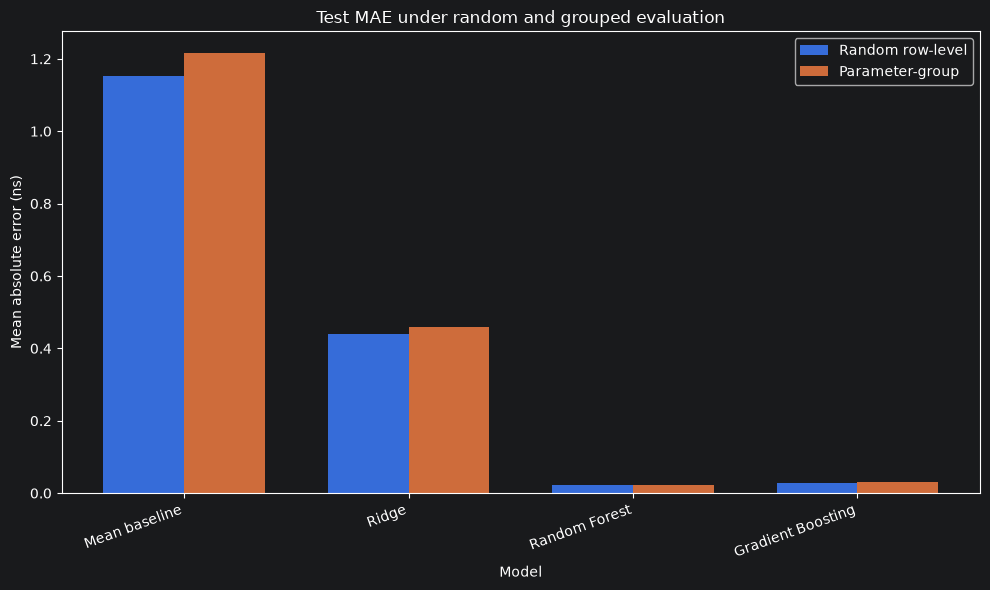

In [130]:
model_positions = np.arange(
    len(expected_model_names),
    dtype=np.float64,
)

bar_width = 0.36

random_mae_values = (
    mae_comparison["Random row-level"].to_numpy()
)

grouped_mae_values = (
    mae_comparison["Parameter-group"].to_numpy()
)

plt.figure(figsize=(10, 6))

plt.bar(
    model_positions - bar_width / 2,
    random_mae_values,
    width=bar_width,
    label="Random row-level",
)

plt.bar(
    model_positions + bar_width / 2,
    grouped_mae_values,
    width=bar_width,
    label="Parameter-group",
)

plt.xticks(
    model_positions,
    expected_model_names,
    rotation=20,
    ha="right",
)

plt.xlabel("Model")
plt.ylabel("Mean absolute error (ns)")
plt.title(
    "Test MAE under random and grouped evaluation"
)
plt.legend()
plt.tight_layout()
plt.show()

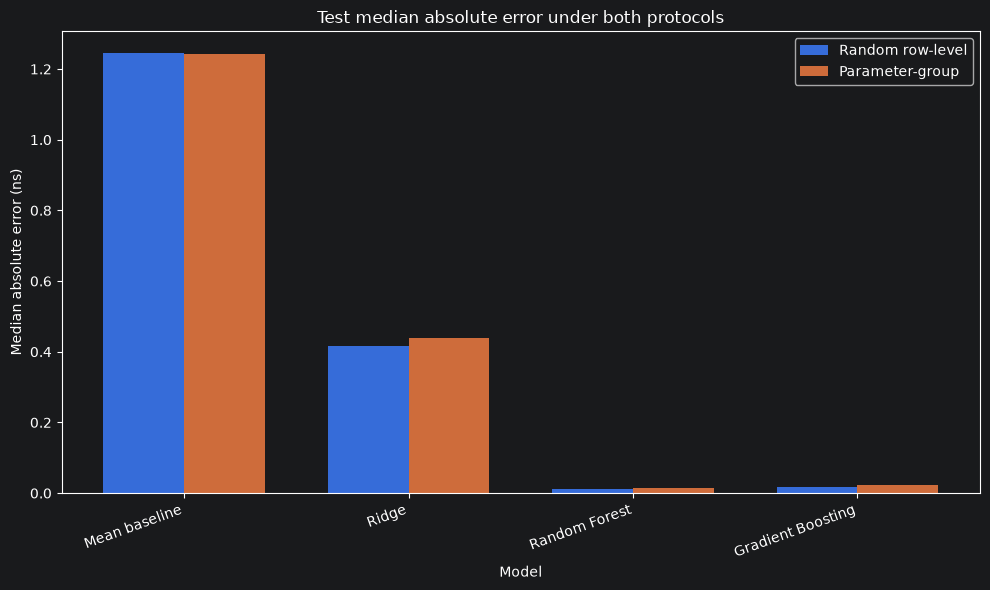

In [131]:
random_median_error_values = (
    median_error_comparison[
        "Random row-level"
    ].to_numpy()
)

grouped_median_error_values = (
    median_error_comparison[
        "Parameter-group"
    ].to_numpy()
)

plt.figure(figsize=(10, 6))

plt.bar(
    model_positions - bar_width / 2,
    random_median_error_values,
    width=bar_width,
    label="Random row-level",
)

plt.bar(
    model_positions + bar_width / 2,
    grouped_median_error_values,
    width=bar_width,
    label="Parameter-group",
)

plt.xticks(
    model_positions,
    expected_model_names,
    rotation=20,
    ha="right",
)

plt.xlabel("Model")
plt.ylabel("Median absolute error (ns)")
plt.title(
    "Test median absolute error under both protocols"
)
plt.legend()
plt.tight_layout()
plt.show()

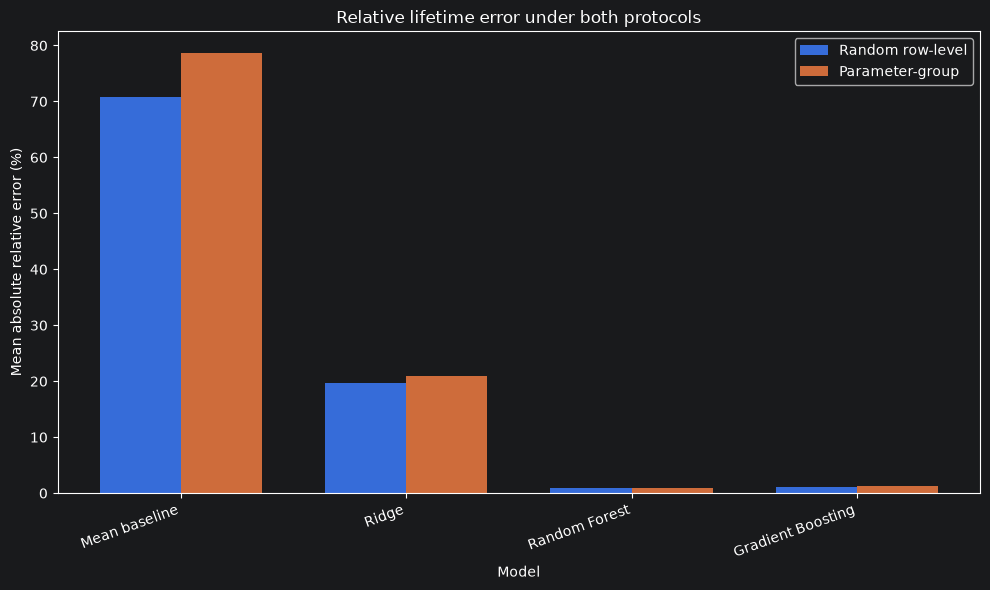

In [132]:
random_relative_error_values = (
    relative_error_comparison[
        "Random row-level"
    ].to_numpy()
)

grouped_relative_error_values = (
    relative_error_comparison[
        "Parameter-group"
    ].to_numpy()
)

plt.figure(figsize=(10, 6))

plt.bar(
    model_positions - bar_width / 2,
    random_relative_error_values,
    width=bar_width,
    label="Random row-level",
)

plt.bar(
    model_positions + bar_width / 2,
    grouped_relative_error_values,
    width=bar_width,
    label="Parameter-group",
)

plt.xticks(
    model_positions,
    expected_model_names,
    rotation=20,
    ha="right",
)

plt.xlabel("Model")
plt.ylabel("Mean absolute relative error (%)")
plt.title(
    "Relative lifetime error under both protocols"
)
plt.legend()
plt.tight_layout()
plt.show()

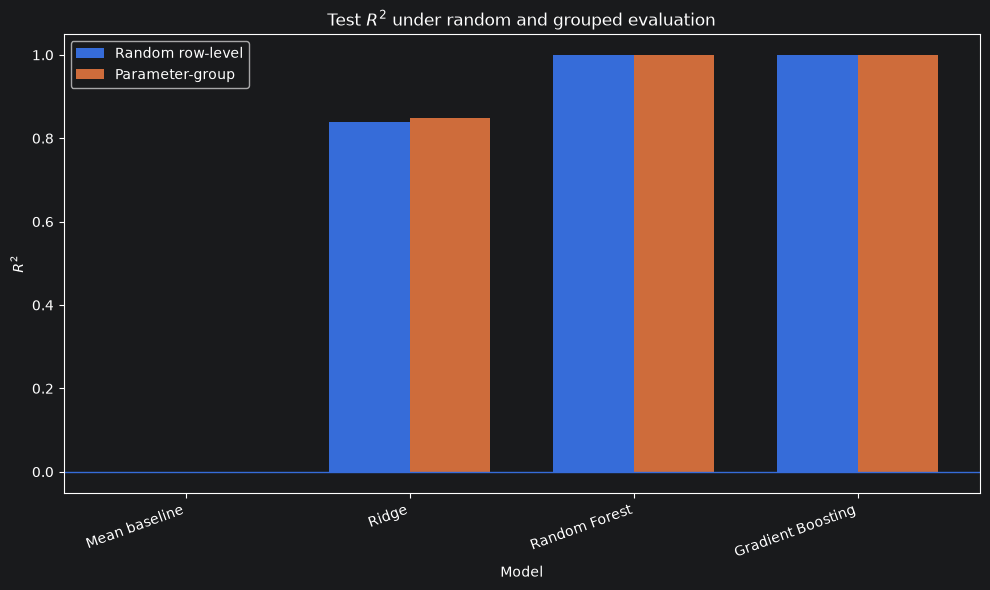

In [133]:
random_r2_values = (
    r2_comparison["Random row-level"].to_numpy()
)

grouped_r2_values = (
    r2_comparison["Parameter-group"].to_numpy()
)

plt.figure(figsize=(10, 6))

plt.bar(
    model_positions - bar_width / 2,
    random_r2_values,
    width=bar_width,
    label="Random row-level",
)

plt.bar(
    model_positions + bar_width / 2,
    grouped_r2_values,
    width=bar_width,
    label="Parameter-group",
)

plt.axhline(
    y=0.0,
    linewidth=1.0,
)

plt.xticks(
    model_positions,
    expected_model_names,
    rotation=20,
    ha="right",
)

plt.xlabel("Model")
plt.ylabel(r"$R^2$")
plt.title(
    r"Test $R^2$ under random and grouped evaluation"
)
plt.legend()
plt.tight_layout()
plt.show()

### Best-performing model under each protocol

The model with the smallest MAE is identified separately for the random and grouped test sets.

The best model need not be the same under both protocols. A model that performs especially well on familiar parameter groups may not retain the same advantage when evaluated on completely held-out groups.

In [134]:
best_model_rows = []

for protocol_name in protocol_order:
    protocol_results = metric_results.loc[
        metric_results["protocol"] == protocol_name
    ]

    best_row_index = protocol_results[
        "mae_ns"
    ].idxmin()

    best_row = metric_results.loc[
        best_row_index
    ]

    best_model_rows.append(
        {
            "protocol": protocol_name,
            "best_model_by_mae": best_row["model"],
            "best_mae_ns": best_row["mae_ns"],
            "median_absolute_error_ns": (
                best_row["median_absolute_error_ns"]
            ),
            "mean_absolute_relative_error_percent": (
                best_row[
                    "mean_absolute_relative_error_percent"
                ]
            ),
            "r2": best_row["r2"],
        }
    )

best_model_summary = pd.DataFrame(
    best_model_rows
)

best_model_summary.round(
    {
        "best_mae_ns": 4,
        "median_absolute_error_ns": 4,
        "mean_absolute_relative_error_percent": 2,
        "r2": 4,
    }
)

,protocol,best_model_by_mae,best_mae_ns,median_absolute_error_ns,mean_absolute_relative_error_percent,r2
0,Random row-level,Random Forest,0.0220,0.0127,0.88,0.9993
1,Parameter-group,Random Forest,0.0229,0.0149,0.97,0.9993


In [135]:
baseline_mae_by_protocol = (
    metric_results.loc[
        metric_results["model"] == "Mean baseline",
        [
            "protocol",
            "mae_ns",
        ],
    ]
    .set_index("protocol")["mae_ns"]
)

metric_results_with_baseline = metric_results.copy()

metric_results_with_baseline[
    "mean_baseline_mae_ns"
] = (
    metric_results_with_baseline[
        "protocol"
    ].map(baseline_mae_by_protocol)
)

metric_results_with_baseline[
    "mae_improvement_over_baseline_percent"
] = (
    100.0
    * (
        1.0
        - metric_results_with_baseline["mae_ns"]
        / metric_results_with_baseline[
            "mean_baseline_mae_ns"
        ]
    )
)

metric_results_with_baseline.round(
    {
        "mae_ns": 4,
        "mean_baseline_mae_ns": 4,
        "mae_improvement_over_baseline_percent": 1,
    }
)

,protocol,model,mae_ns,median_absolute_error_ns,mean_absolute_relative_error_percent,median_absolute_relative_error_percent,r2,mean_baseline_mae_ns,mae_improvement_over_baseline_percent
0,Random row-level,Mean baseline,1.1516,1.244408,70.740285,35.653954,-0.001298,1.1516,0.0
1,Random row-level,Ridge,0.4408,0.417662,19.711572,18.253512,0.839982,1.1516,61.7
2,Random row-level,Random Forest,0.0220,0.012704,0.880952,0.577919,0.999266,1.1516,98.1
3,Random row-level,Gradient Boosting,0.0271,0.018108,1.167676,0.800240,0.999106,1.1516,97.6
4,Parameter-group,Mean baseline,1.2152,1.241192,78.596542,37.234271,-0.000642,1.2152,0.0
5,Parameter-group,Ridge,0.4587,0.438607,20.920816,18.719343,0.847796,1.2152,62.3
6,Parameter-group,Random Forest,0.0229,0.014879,0.969337,0.669203,0.999298,1.2152,98.1
7,Parameter-group,Gradient Boosting,0.0299,0.022664,1.268709,0.874397,0.999030,1.2152,97.5


In [136]:
baseline_improvement_values = (
    metric_results_with_baseline.loc[
        metric_results_with_baseline[
            "model"
        ] == "Mean baseline",
        "mae_improvement_over_baseline_percent",
    ]
)

assert np.allclose(
    baseline_improvement_values,
    0.0,
)

### Protocol sensitivity of the learned models

The performance change between the random and grouped protocols is especially important for the learned regressors.

A large increase in error under grouped evaluation suggests that the random split benefited from having related Poisson realizations of the test parameter groups in training.

A small difference suggests that the model generalizes similarly to new realizations and to new parameter combinations within the simulated range.

In [137]:
learned_model_mae_sensitivity = (
    mae_comparison.loc[
        [
            "Ridge",
            "Random Forest",
            "Gradient Boosting",
        ]
    ]
    .copy()
)

learned_model_mae_sensitivity.round(
    {
        "Random row-level": 4,
        "Parameter-group": 4,
        "grouped_minus_random_mae_ns": 4,
        "grouped_to_random_mae_ratio": 3,
        "grouped_mae_increase_percent": 1,
    }
)

protocol,Random row-level,Parameter-group,grouped_minus_random_mae_ns,grouped_to_random_mae_ratio,grouped_mae_increase_percent
model,,,,,
Ridge,0.4408,0.4587,0.0179,1.041,4.1
Random Forest,0.0220,0.0229,0.0009,1.040,4.0
Gradient Boosting,0.0271,0.0299,0.0028,1.103,10.3


In [138]:
def classify_mae_change(
    grouped_mae_increase_percent: float,
) -> str:
    """Describe the direction and size of an MAE change."""
    if grouped_mae_increase_percent > 10.0:
        return "substantially higher under grouped split"

    if grouped_mae_increase_percent > 2.0:
        return "moderately higher under grouped split"

    if grouped_mae_increase_percent >= -2.0:
        return "approximately unchanged"

    return "lower under grouped split"

learned_model_mae_sensitivity[
    "interpretation"
] = (
    learned_model_mae_sensitivity[
        "grouped_mae_increase_percent"
    ].apply(classify_mae_change)
)

learned_model_mae_sensitivity

protocol,Random row-level,Parameter-group,grouped_minus_random_mae_ns,grouped_to_random_mae_ratio,grouped_mae_increase_percent,interpretation
model,,,,,,
Ridge,0.440765,0.458656,0.017891,1.040591,4.059107,moderately higher under grouped split
Random Forest,0.022035,0.022911,0.000875,1.039722,3.972163,moderately higher under grouped split
Gradient Boosting,0.027132,0.029933,0.002802,1.103256,10.325614,substantially higher under grouped split


### Signed prediction residuals

Absolute metrics describe error magnitude but not direction. Signed residuals are therefore summarized to identify systematic overestimation or underestimation.

The prediction residual is defined as

$$
r_i
=
\hat{\tau}_i-\tau_i.
$$

A positive mean residual indicates overall overestimation, while a negative mean residual indicates overall underestimation.

In [139]:
residual_summary_rows = []

for protocol_name, y_true, predictions in [
    (
        "Random row-level",
        y_test_random,
        predictions_random,
    ),
    (
        "Parameter-group",
        y_test_grouped,
        predictions_grouped,
    ),
]:
    for model_name, model_predictions in predictions.items():
        residuals = model_predictions - y_true

        residual_summary_rows.append(
            {
                "protocol": protocol_name,
                "model": model_name,
                "mean_residual_ns": float(
                    np.mean(residuals)
                ),
                "median_residual_ns": float(
                    np.median(residuals)
                ),
                "residual_standard_deviation_ns": float(
                    np.std(residuals)
                ),
            }
        )

residual_summary = pd.DataFrame(
    residual_summary_rows
)

residual_summary.round(4)

,protocol,model,mean_residual_ns,median_residual_ns,residual_standard_deviation_ns
0,Random row-level,Mean baseline,0.0474,0.0319,1.3143
1,Random row-level,Ridge,-0.0023,0.1496,0.5257
2,Random row-level,Random Forest,0.0029,-0.0011,0.0355
3,Random row-level,Gradient Boosting,-0.0008,-0.0024,0.0393
4,Parameter-group,Mean baseline,0.0344,-0.0370,1.3592
5,Parameter-group,Ridge,-0.0562,-0.0055,0.5273
6,Parameter-group,Random Forest,0.0031,-0.0014,0.0359
7,Parameter-group,Gradient Boosting,0.0030,-0.0006,0.0422


In [140]:
final_metric_comparison = (
    metric_results
    .loc[
        :,
        [
            "protocol",
            "model",
            "mae_ns",
            "median_absolute_error_ns",
            "mean_absolute_relative_error_percent",
            "median_absolute_relative_error_percent",
            "r2",
        ],
    ]
    .copy()
)

final_metric_comparison = (
    final_metric_comparison
    .sort_values(
        by=[
            "protocol",
            "mae_ns",
        ],
        ascending=[
            True,
            True,
        ],
    )
    .reset_index(drop=True)
)

final_metric_comparison.round(
    {
        "mae_ns": 4,
        "median_absolute_error_ns": 4,
        "mean_absolute_relative_error_percent": 2,
        "median_absolute_relative_error_percent": 2,
        "r2": 4,
    }
)

,protocol,model,mae_ns,median_absolute_error_ns,mean_absolute_relative_error_percent,median_absolute_relative_error_percent,r2
0,Parameter-group,Random Forest,0.0229,0.0149,0.97,0.67,0.9993
1,Parameter-group,Gradient Boosting,0.0299,0.0227,1.27,0.87,0.9990
2,Parameter-group,Ridge,0.4587,0.4386,20.92,18.72,0.8478
3,Parameter-group,Mean baseline,1.2152,1.2412,78.60,37.23,-0.0006
4,Random row-level,Random Forest,0.0220,0.0127,0.88,0.58,0.9993
5,Random row-level,Gradient Boosting,0.0271,0.0181,1.17,0.80,0.9991
6,Random row-level,Ridge,0.4408,0.4177,19.71,18.25,0.8400
7,Random row-level,Mean baseline,1.1516,1.2444,70.74,35.65,-0.0013


In [141]:
final_metric_comparison[
    "protocol"
] = pd.Categorical(
    final_metric_comparison["protocol"],
    categories=protocol_order,
    ordered=True,
)

final_metric_comparison = (
    final_metric_comparison
    .sort_values(
        by=[
            "protocol",
            "mae_ns",
        ]
    )
    .reset_index(drop=True)
)

final_metric_comparison.round(
    {
        "mae_ns": 4,
        "median_absolute_error_ns": 4,
        "mean_absolute_relative_error_percent": 2,
        "median_absolute_relative_error_percent": 2,
        "r2": 4,
    }
)

,protocol,model,mae_ns,median_absolute_error_ns,mean_absolute_relative_error_percent,median_absolute_relative_error_percent,r2
0,Random row-level,Random Forest,0.0220,0.0127,0.88,0.58,0.9993
1,Random row-level,Gradient Boosting,0.0271,0.0181,1.17,0.80,0.9991
2,Random row-level,Ridge,0.4408,0.4177,19.71,18.25,0.8400
3,Random row-level,Mean baseline,1.1516,1.2444,70.74,35.65,-0.0013
4,Parameter-group,Random Forest,0.0229,0.0149,0.97,0.67,0.9993
5,Parameter-group,Gradient Boosting,0.0299,0.0227,1.27,0.87,0.9990
6,Parameter-group,Ridge,0.4587,0.4386,20.92,18.72,0.8478
7,Parameter-group,Mean baseline,1.2152,1.2412,78.60,37.23,-0.0006


### Interpretation of metric comparison

All three learned regressors outperform the mean-prediction baseline under both evaluation protocols. This confirms that the normalized TCSPC histogram shapes contain substantial information about fluorescence lifetime.

The mean baseline produces an MAE of `1.1516 ns` under the random row-level split and `1.2152 ns` under the parameter-group split, with (R^2) values close to zero. In contrast, Ridge regression reduces the MAE to `0.4408 ns` and `0.4587 ns`, respectively, while the two tree-based models achieve much smaller errors.

Random Forest is the best-performing model under both protocols. Its MAE changes from `0.0220 ns` under the random row-level split to `0.0229 ns` under the parameter-group split. Its mean absolute relative error increases only from `0.88%` to `0.97%`, while (R^2) remains approximately `0.9993` in both cases.

Gradient Boosting is the second-best model. Its MAE increases from `0.0271 ns` to `0.0299 ns`, corresponding to a relative increase of approximately `10.3%`. Its mean absolute relative error changes from `1.17%` to `1.27%`, while (R^2) remains close to `0.999`.

Ridge regression is substantially less accurate than the tree-based models but still clearly outperforms the mean baseline. Its MAE increases from `0.4408 ns` under the random split to `0.4587 ns` under the grouped split, an increase of approximately `4.1%`. Its mean absolute relative error rises from `19.71%` to `20.92%`.

The median errors show the same general pattern as the mean errors. For Random Forest, the median absolute error increases from `0.0127 ns` to `0.0149 ns`. For Gradient Boosting, it increases from `0.0181 ns` to `0.0227 ns`, and for Ridge it increases from `0.4177 ns` to `0.4386 ns`. The grouped protocol therefore causes a broad but relatively modest deterioration rather than only a few isolated large errors.

The signed residuals of the tree-based models remain very close to zero under both protocols. Random Forest has mean residuals of approximately `0.0029 ns` and `0.0031 ns`, while Gradient Boosting has mean residuals of approximately `-0.0008 ns` and `0.0030 ns`. This indicates little systematic overestimation or underestimation. Ridge shows a larger negative mean residual of `-0.0562 ns` under the grouped split, indicating some overall underestimation in that test set.

The grouped split produces higher MAE for all three learned models:

* Ridge: approximately `4.1%` higher;
* Random Forest: approximately `4.0%` higher;
* Gradient Boosting: approximately `10.3%` higher.

This confirms that the random row-level split gives slightly more optimistic results because many test parameter groups are already represented by related Poisson realizations in the training set. However, the deterioration under the grouped split is not dramatic, especially for Random Forest. The tree-based models retain excellent performance when evaluated on completely unseen lifetime–amplitude–background combinations sampled from the same overall parameter ranges.

The parameter-group results should therefore be treated as the more defensible estimate of interpolation performance. For the current idealized simulated dataset, Random Forest demonstrates the strongest and most stable generalization, followed closely by Gradient Boosting. These conclusions remain limited to mono-exponential, Poisson-sampled curves without IRF convolution or other forms of model mismatch.


### Conclusions from the metric comparison

The evaluation protocol is part of the scientific definition of model performance.

A random row-level split and a parameter-group split may use:

* the same number of curves;
* the same feature representation;
* the same models;
* the same hyperparameters;
* the same error metrics.

Nevertheless, they answer different questions.

The random row-level protocol estimates performance on individual Poisson realizations withheld from a simulation campaign in which related realizations of the same expected curves may remain in training.

The parameter-group protocol estimates performance on Poisson-sampled curves whose complete lifetime–amplitude–background combinations were absent from training.

If the random protocol produces substantially better scores, the difference should not be described as additional model capability. It indicates that the random test set was physically more familiar to the model.

The grouped test metrics therefore provide the primary estimate of interpolation performance for new simulation parameter combinations within the same parameter ranges.

The next section examines prediction error as a function of true lifetime. This tests whether the average metrics conceal regions in which the models perform systematically better or worse.

## 8. Error dependence and final conclusions

Global metrics such as MAE and $R^2$ summarize model performance over the complete test set, but they do not show whether prediction quality is uniform across the simulated parameter space.

A low overall MAE may conceal systematic weaknesses in particular regions. For example, a model may perform less accurately for:

* very short lifetimes;
* very long lifetimes;
* low-photon curves with strong relative Poisson fluctuations;
* parameter regions that are sparsely represented in the test set.

This final section therefore evaluates error as a function of:

1. the true fluorescence lifetime;
2. the measured total photon count.

Both splitting protocols are retained for comparison, although the parameter-group results provide the more defensible estimate of interpolation performance for unfamiliar simulation parameter combinations.

The section concludes by summarizing the principal findings and the scientific limitations of the present experiment.

### Sample-level prediction errors

Conditional error analysis requires retaining the error of every individual test prediction rather than immediately averaging over the complete test set.

For each test curve, the following quantities are stored:

* the true lifetime;
* the predicted lifetime;
* the signed residual;
* the absolute error;
* the absolute relative error;
* the measured total photon count;
* the parameter-group identifier.

These values are combined into a long-form table containing one row for every model–curve combination.

In [142]:
def build_sample_error_table(
    protocol_name: str,
    y_true: np.ndarray,
    predictions: dict[str, np.ndarray],
    metadata: pd.DataFrame,
) -> pd.DataFrame:
    """Build one sample-level error table for a test protocol."""
    if y_true.ndim != 1:
        raise ValueError("y_true must be one-dimensional.")

    if len(metadata) != y_true.size:
        raise ValueError(
            "metadata and y_true must describe the same "
            "number of samples."
        )

    required_columns = {
        "curve_id",
        "parameter_group",
        "lifetime_ns",
        "measured_total_counts",
    }

    missing_columns = (
        required_columns - set(metadata.columns)
    )

    if missing_columns:
        raise ValueError(
            "metadata is missing required columns: "
            f"{sorted(missing_columns)}"
        )

    if not np.allclose(
        metadata["lifetime_ns"].to_numpy(),
        y_true,
    ):
        raise ValueError(
            "Metadata lifetimes do not match y_true."
        )

    result_tables: list[pd.DataFrame] = []

    for model_name, y_pred in predictions.items():
        if y_pred.shape != y_true.shape:
            raise ValueError(
                f"Prediction shape mismatch for {model_name}."
            )

        residuals = y_pred - y_true
        absolute_errors = np.abs(residuals)
        relative_errors_percent = (
            100.0 * absolute_errors / y_true
        )

        model_table = pd.DataFrame(
            {
                "protocol": protocol_name,
                "model": model_name,
                "curve_id": metadata[
                    "curve_id"
                ].to_numpy(),
                "parameter_group": metadata[
                    "parameter_group"
                ].to_numpy(),
                "true_lifetime_ns": y_true,
                "predicted_lifetime_ns": y_pred,
                "residual_ns": residuals,
                "absolute_error_ns": absolute_errors,
                "absolute_relative_error_percent": (
                    relative_errors_percent
                ),
                "measured_total_counts": metadata[
                    "measured_total_counts"
                ].to_numpy(),
            }
        )

        result_tables.append(model_table)

    return pd.concat(
        result_tables,
        ignore_index=True,
    )

In [143]:
sample_errors_random = build_sample_error_table(
    protocol_name="Random row-level",
    y_true=y_test_random,
    predictions=predictions_random,
    metadata=metadata_test_random,
)

sample_errors_grouped = build_sample_error_table(
    protocol_name="Parameter-group",
    y_true=y_test_grouped,
    predictions=predictions_grouped,
    metadata=metadata_test_grouped,
)

sample_errors = pd.concat(
    [
        sample_errors_random,
        sample_errors_grouped,
    ],
    ignore_index=True,
)

sample_errors.shape

(4000, 10)

In [144]:
sample_errors.head()

,protocol,model,curve_id,parameter_group,true_lifetime_ns,predicted_lifetime_ns,residual_ns,absolute_error_ns,absolute_relative_error_percent,measured_total_counts
0,Random row-level,Mean baseline,1447,289,0.957524,2.740038,1.782514,1.782514,186.158809,131035
1,Random row-level,Mean baseline,1114,222,3.482889,2.740038,-0.742851,0.742851,21.328585,62958
2,Random row-level,Mean baseline,1064,212,1.398990,2.740038,1.341048,1.341048,95.858239,250988
3,Random row-level,Mean baseline,2287,457,2.563523,2.740038,0.176515,0.176515,6.885647,295417
4,Random row-level,Mean baseline,1537,307,3.378035,2.740038,-0.637997,0.637997,18.886623,152135


In [145]:
expected_rows_per_protocol = (
    y_test_random.size
    * len(expected_model_names)
)

assert len(sample_errors_random) == (
    expected_rows_per_protocol
)

assert len(sample_errors_grouped) == (
    expected_rows_per_protocol
)

assert len(sample_errors) == (
    2 * expected_rows_per_protocol
)

In [146]:
assert set(sample_errors["protocol"]) == {
    "Random row-level",
    "Parameter-group",
}

assert set(sample_errors["model"]) == set(
    expected_model_names
)

In [147]:
sample_error_numeric_columns = [
    "true_lifetime_ns",
    "predicted_lifetime_ns",
    "residual_ns",
    "absolute_error_ns",
    "absolute_relative_error_percent",
    "measured_total_counts",
]

assert np.all(
    np.isfinite(
        sample_errors[
            sample_error_numeric_columns
        ].to_numpy()
    )
)

assert np.all(
    sample_errors["absolute_error_ns"].to_numpy()
    >= 0.0
)

assert np.all(
    sample_errors[
        "absolute_relative_error_percent"
    ].to_numpy()
    >= 0.0
)

In [148]:
sample_level_mae_check = (
    sample_errors
    .groupby(
        [
            "protocol",
            "model",
        ],
        as_index=False,
    )["absolute_error_ns"]
    .mean()
    .rename(
        columns={
            "absolute_error_ns": (
                "sample_level_mae_ns"
            )
        }
    )
)

sample_level_mae_check

,protocol,model,sample_level_mae_ns
0,Parameter-group,Gradient Boosting,0.029933
1,Parameter-group,Mean baseline,1.215243
2,Parameter-group,Random Forest,0.022911
3,Parameter-group,Ridge,0.458656
4,Random row-level,Gradient Boosting,0.027132
5,Random row-level,Mean baseline,1.151632
6,Random row-level,Random Forest,0.022035
7,Random row-level,Ridge,0.440765


In [149]:
mae_consistency_check = (
    metric_results[
        [
            "protocol",
            "model",
            "mae_ns",
        ]
    ]
    .merge(
        sample_level_mae_check,
        on=[
            "protocol",
            "model",
        ],
        validate="one_to_one",
    )
)

mae_consistency_check[
    "absolute_difference"
] = np.abs(
    mae_consistency_check["mae_ns"]
    - mae_consistency_check[
        "sample_level_mae_ns"
    ]
)

mae_consistency_check

,protocol,model,mae_ns,sample_level_mae_ns,absolute_difference
0,Random row-level,Mean baseline,1.151632,1.151632,2.220446e-16
1,Random row-level,Ridge,0.440765,0.440765,5.551115e-17
2,Random row-level,Random Forest,0.022035,0.022035,3.469447e-18
3,Random row-level,Gradient Boosting,0.027132,0.027132,0.000000e+00
4,Parameter-group,Mean baseline,1.215243,1.215243,0.000000e+00
5,Parameter-group,Ridge,0.458656,0.458656,5.551115e-17
6,Parameter-group,Random Forest,0.022911,0.022911,0.000000e+00
7,Parameter-group,Gradient Boosting,0.029933,0.029933,0.000000e+00


In [150]:
assert np.allclose(
    mae_consistency_check["mae_ns"],
    mae_consistency_check[
        "sample_level_mae_ns"
    ],
)

### Lifetime-dependent error analysis

The simulated lifetime interval from `0.5 ns` to `5.0 ns` is divided into equal-width bins.

For every model, protocol, and lifetime bin, the following quantities are calculated:

* number of test curves;
* mean true lifetime;
* mean absolute error;
* median absolute error;
* mean absolute relative error;
* mean signed residual.

Absolute error shows the error in nanoseconds, while relative error accounts for the fact that the same absolute deviation represents a larger fraction of a short lifetime than of a long lifetime.

In [151]:
n_lifetime_bins = 10

lifetime_analysis_edges = np.linspace(
    lifetime_range_ns[0],
    lifetime_range_ns[1],
    n_lifetime_bins + 1,
)

lifetime_analysis_edges

array([0.5 , 0.95, 1.4 , 1.85, 2.3 , 2.75, 3.2 , 3.65, 4.1 , 4.55, 5.  ])

In [152]:
sample_errors["lifetime_bin"] = pd.cut(
    sample_errors["true_lifetime_ns"],
    bins=lifetime_analysis_edges,
    include_lowest=True,
    right=True,
)

In [153]:
assert sample_errors[
    "lifetime_bin"
].notna().all()

In [154]:
lifetime_bin_counts = (
    sample_errors.loc[
        sample_errors["model"] == "Random Forest"
    ]
    .groupby(
        [
            "protocol",
            "lifetime_bin",
        ],
        observed=True,
    )
    .size()
    .rename("n_test_curves")
    .reset_index()
)

lifetime_bin_counts

,protocol,lifetime_bin,n_test_curves
0,Parameter-group,"(0.499, 0.95]",50
1,Parameter-group,"(0.95, 1.4]",70
2,Parameter-group,"(1.4, 1.85]",55
3,Parameter-group,"(1.85, 2.3]",40
4,Parameter-group,"(2.3, 2.75]",30
5,Parameter-group,"(2.75, 3.2]",40
6,Parameter-group,"(3.2, 3.65]",55
7,Parameter-group,"(3.65, 4.1]",60
8,Parameter-group,"(4.1, 4.55]",65
9,Parameter-group,"(4.55, 5.0]",35


In [155]:
lifetime_error_summary = (
    sample_errors
    .groupby(
        [
            "protocol",
            "model",
            "lifetime_bin",
        ],
        observed=True,
    )
    .agg(
        n_test_curves=(
            "curve_id",
            "size",
        ),
        mean_true_lifetime_ns=(
            "true_lifetime_ns",
            "mean",
        ),
        mae_ns=(
            "absolute_error_ns",
            "mean",
        ),
        median_absolute_error_ns=(
            "absolute_error_ns",
            "median",
        ),
        mean_absolute_relative_error_percent=(
            "absolute_relative_error_percent",
            "mean",
        ),
        mean_residual_ns=(
            "residual_ns",
            "mean",
        ),
    )
    .reset_index()
)

lifetime_error_summary.head(15)

,protocol,model,lifetime_bin,n_test_curves,mean_true_lifetime_ns,mae_ns,median_absolute_error_ns,mean_absolute_relative_error_percent,mean_residual_ns
0,Parameter-group,Gradient Boosting,"(0.499, 0.95]",50,0.657113,0.010118,0.008382,1.584779,0.003157
1,Parameter-group,Gradient Boosting,"(0.95, 1.4]",70,1.094937,0.020492,0.015542,1.901453,0.000876
2,Parameter-group,Gradient Boosting,"(1.4, 1.85]",55,1.640517,0.028875,0.022460,1.752093,0.010066
3,Parameter-group,Gradient Boosting,"(1.85, 2.3]",40,2.090110,0.028204,0.022624,1.334926,-0.004379
4,Parameter-group,Gradient Boosting,"(2.3, 2.75]",30,2.497422,0.020599,0.010189,0.817092,-0.006040
5,Parameter-group,Gradient Boosting,"(2.75, 3.2]",40,2.928534,0.022949,0.020931,0.789342,-0.005504
6,Parameter-group,Gradient Boosting,"(3.2, 3.65]",55,3.486974,0.035408,0.027132,1.029905,0.005659
7,Parameter-group,Gradient Boosting,"(3.65, 4.1]",60,3.920041,0.031210,0.025904,0.799755,0.005060
8,Parameter-group,Gradient Boosting,"(4.1, 4.55]",65,4.337513,0.057433,0.043329,1.324258,0.014119
9,Parameter-group,Gradient Boosting,"(4.55, 5.0]",35,4.776769,0.034885,0.036842,0.727376,-0.005880


In [156]:
lifetime_error_summary[
    "lifetime_bin_center_ns"
] = lifetime_error_summary[
    "lifetime_bin"
].apply(
    lambda interval: float(interval.mid)
)

lifetime_error_summary.head()

,protocol,model,lifetime_bin,n_test_curves,mean_true_lifetime_ns,mae_ns,median_absolute_error_ns,mean_absolute_relative_error_percent,mean_residual_ns,lifetime_bin_center_ns
0,Parameter-group,Gradient Boosting,"(0.499, 0.95]",50,0.657113,0.010118,0.008382,1.584779,0.003157,0.7245
1,Parameter-group,Gradient Boosting,"(0.95, 1.4]",70,1.094937,0.020492,0.015542,1.901453,0.000876,1.1750
2,Parameter-group,Gradient Boosting,"(1.4, 1.85]",55,1.640517,0.028875,0.022460,1.752093,0.010066,1.6250
3,Parameter-group,Gradient Boosting,"(1.85, 2.3]",40,2.090110,0.028204,0.022624,1.334926,-0.004379,2.0750
4,Parameter-group,Gradient Boosting,"(2.3, 2.75]",30,2.497422,0.020599,0.010189,0.817092,-0.006040,2.5250


In [157]:
lifetime_count_check = (
    lifetime_error_summary
    .groupby(
        [
            "protocol",
            "model",
        ]
    )["n_test_curves"]
    .sum()
)

lifetime_count_check

protocol          model            
Parameter-group   Gradient Boosting    500
                  Mean baseline        500
                  Random Forest        500
                  Ridge                500
Random row-level  Gradient Boosting    500
                  Mean baseline        500
                  Random Forest        500
                  Ridge                500
Name: n_test_curves, dtype: int64

In [158]:
assert np.all(
    lifetime_count_check.to_numpy()
    == y_test_random.size
)

In [159]:
grouped_random_forest_lifetime_errors = (
    lifetime_error_summary.loc[
        (
            lifetime_error_summary["protocol"]
            == "Parameter-group"
        )
        & (
            lifetime_error_summary["model"]
            == "Random Forest"
        )
    ]
    .sort_values("lifetime_bin_center_ns")
    .reset_index(drop=True)
)

grouped_random_forest_lifetime_errors.round(
    {
        "mean_true_lifetime_ns": 3,
        "mae_ns": 4,
        "median_absolute_error_ns": 4,
        "mean_absolute_relative_error_percent": 2,
        "mean_residual_ns": 4,
        "lifetime_bin_center_ns": 3,
    }
)

,protocol,model,lifetime_bin,n_test_curves,mean_true_lifetime_ns,mae_ns,median_absolute_error_ns,mean_absolute_relative_error_percent,mean_residual_ns,lifetime_bin_center_ns
0,Parameter-group,Random Forest,"(0.499, 0.95]",50,0.657,0.0094,0.0071,1.45,-0.0036,0.7245
1,Parameter-group,Random Forest,"(0.95, 1.4]",70,1.095,0.0128,0.0114,1.19,-0.0007,1.1750
2,Parameter-group,Random Forest,"(1.4, 1.85]",55,1.641,0.0250,0.0160,1.51,0.0143,1.6250
3,Parameter-group,Random Forest,"(1.85, 2.3]",40,2.090,0.0175,0.0121,0.82,0.0000,2.0750
4,Parameter-group,Random Forest,"(2.3, 2.75]",30,2.497,0.0168,0.0162,0.67,-0.0036,2.5250
5,Parameter-group,Random Forest,"(2.75, 3.2]",40,2.929,0.0181,0.0124,0.63,-0.0023,2.9750
6,Parameter-group,Random Forest,"(3.2, 3.65]",55,3.487,0.0290,0.0195,0.85,0.0036,3.4250
7,Parameter-group,Random Forest,"(3.65, 4.1]",60,3.920,0.0215,0.0177,0.55,0.0069,3.8750
8,Parameter-group,Random Forest,"(4.1, 4.55]",65,4.338,0.0468,0.0362,1.08,0.0147,4.3250
9,Parameter-group,Random Forest,"(4.55, 5.0]",35,4.777,0.0245,0.0152,0.51,-0.0108,4.7750


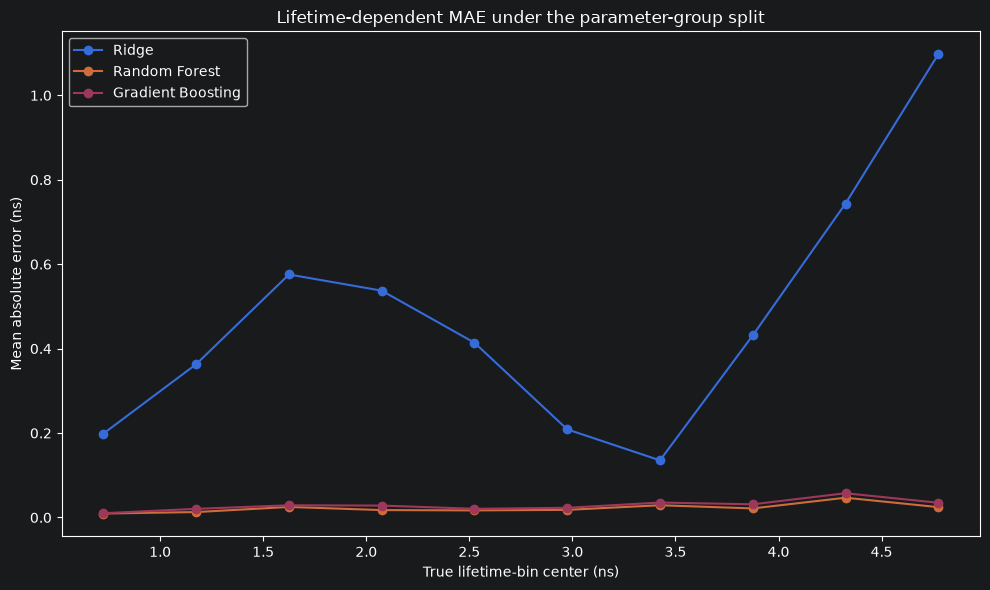

In [160]:
learned_model_names = [
    "Ridge",
    "Random Forest",
    "Gradient Boosting",
]

plt.figure(figsize=(10, 6))

for model_name in learned_model_names:
    model_summary = (
        lifetime_error_summary.loc[
            (
                lifetime_error_summary["protocol"]
                == "Parameter-group"
            )
            & (
                lifetime_error_summary["model"]
                == model_name
            )
        ]
        .sort_values("lifetime_bin_center_ns")
    )

    plt.plot(
        model_summary["lifetime_bin_center_ns"],
        model_summary["mae_ns"],
        marker="o",
        label=model_name,
    )

plt.xlabel("True lifetime-bin center (ns)")
plt.ylabel("Mean absolute error (ns)")
plt.title(
    "Lifetime-dependent MAE under the parameter-group split"
)
plt.legend()
plt.tight_layout()
plt.show()

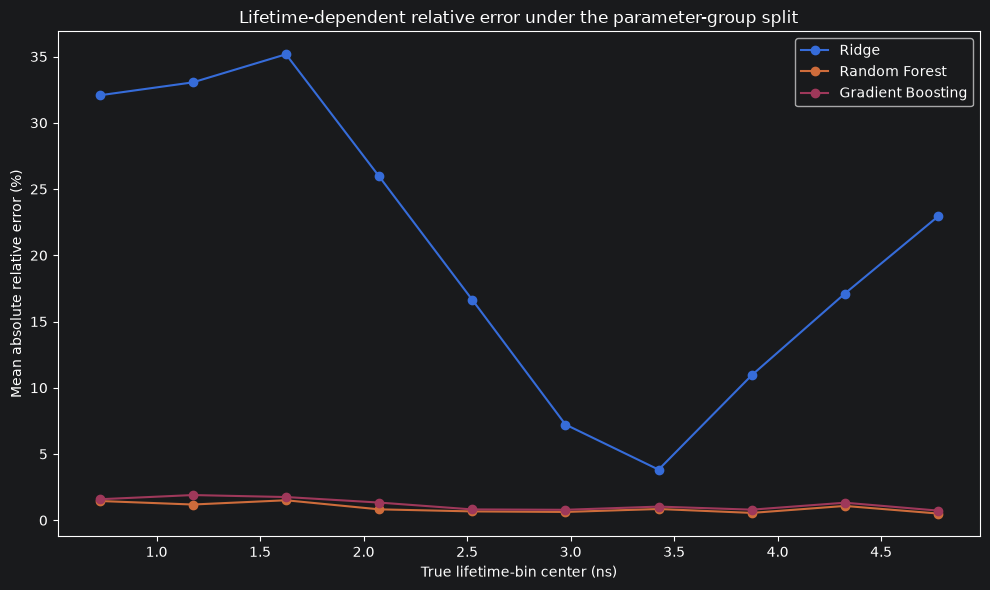

In [161]:
plt.figure(figsize=(10, 6))

for model_name in learned_model_names:
    model_summary = (
        lifetime_error_summary.loc[
            (
                lifetime_error_summary["protocol"]
                == "Parameter-group"
            )
            & (
                lifetime_error_summary["model"]
                == model_name
            )
        ]
        .sort_values("lifetime_bin_center_ns")
    )

    plt.plot(
        model_summary["lifetime_bin_center_ns"],
        model_summary[
            "mean_absolute_relative_error_percent"
        ],
        marker="o",
        label=model_name,
    )

plt.xlabel("True lifetime-bin center (ns)")
plt.ylabel("Mean absolute relative error (%)")
plt.title(
    "Lifetime-dependent relative error under the "
    "parameter-group split"
)
plt.legend()
plt.tight_layout()
plt.show()

### Random Forest protocol comparison across lifetime

Random Forest achieved the smallest global MAE under both protocols. Comparing its lifetime-dependent errors reveals whether the modest global performance difference between the random and grouped splits is concentrated in particular lifetime regions.

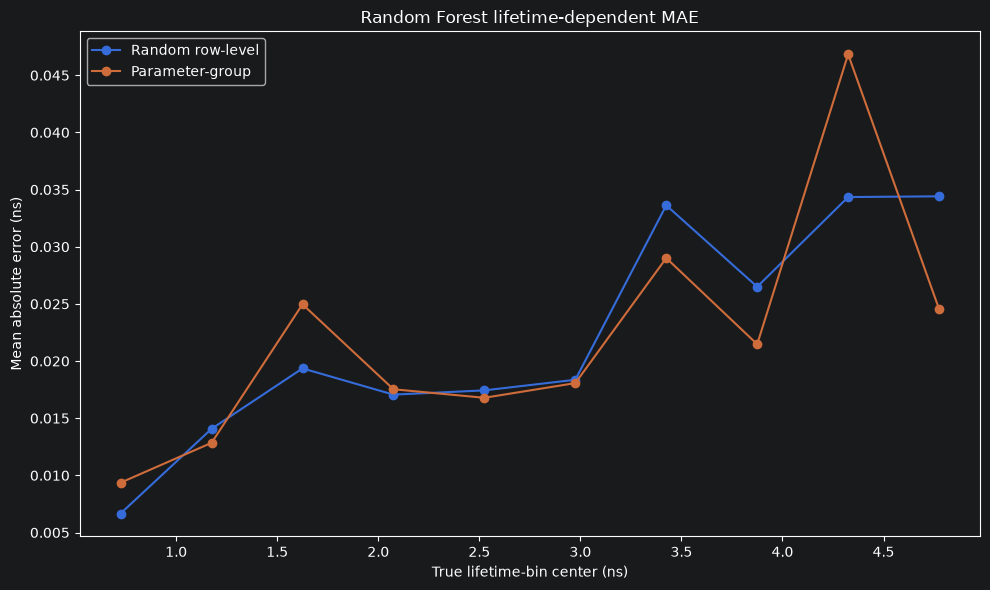

In [162]:
plt.figure(figsize=(10, 6))

for protocol_name in protocol_order:
    protocol_summary = (
        lifetime_error_summary.loc[
            (
                lifetime_error_summary["protocol"]
                == protocol_name
            )
            & (
                lifetime_error_summary["model"]
                == "Random Forest"
            )
        ]
        .sort_values("lifetime_bin_center_ns")
    )

    plt.plot(
        protocol_summary["lifetime_bin_center_ns"],
        protocol_summary["mae_ns"],
        marker="o",
        label=protocol_name,
    )

plt.xlabel("True lifetime-bin center (ns)")
plt.ylabel("Mean absolute error (ns)")
plt.title(
    "Random Forest lifetime-dependent MAE"
)
plt.legend()
plt.tight_layout()
plt.show()

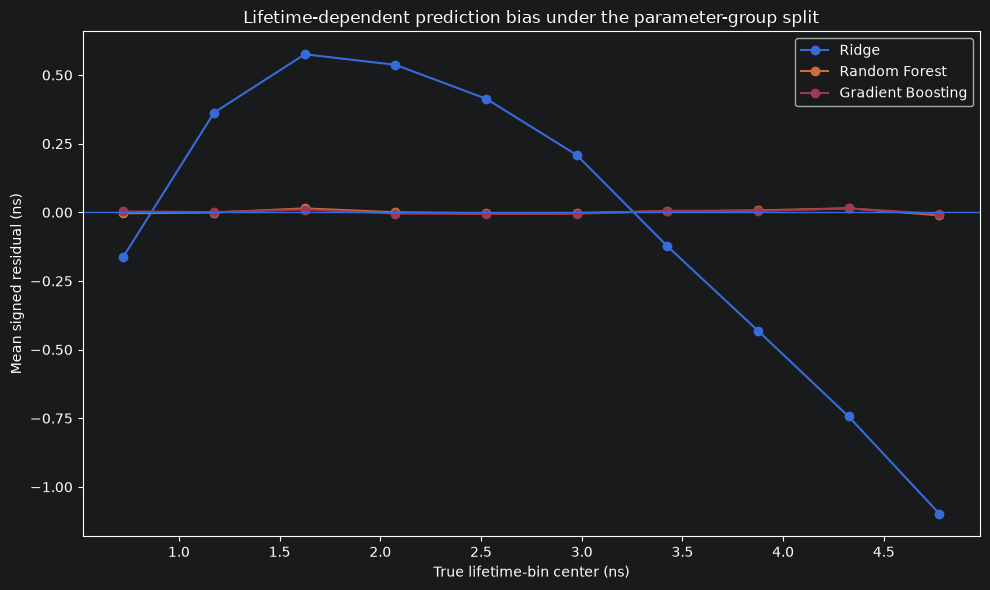

In [163]:
plt.figure(figsize=(10, 6))

for model_name in learned_model_names:
    model_summary = (
        lifetime_error_summary.loc[
            (
                lifetime_error_summary["protocol"]
                == "Parameter-group"
            )
            & (
                lifetime_error_summary["model"]
                == model_name
            )
        ]
        .sort_values("lifetime_bin_center_ns")
    )

    plt.plot(
        model_summary["lifetime_bin_center_ns"],
        model_summary["mean_residual_ns"],
        marker="o",
        label=model_name,
    )

plt.axhline(
    y=0.0,
    linewidth=1.0,
)

plt.xlabel("True lifetime-bin center (ns)")
plt.ylabel("Mean signed residual (ns)")
plt.title(
    "Lifetime-dependent prediction bias under the "
    "parameter-group split"
)
plt.legend()
plt.tight_layout()
plt.show()

### Photon-count-dependent error analysis

For Poisson-distributed counts, the standard deviation in one bin is

$$
\sigma=\sqrt{\lambda},
$$

while the relative fluctuation is approximately

$$
\frac{\sigma}{\lambda}
=
\frac{1}{\sqrt{\lambda}}.
$$

Curves with fewer detected photons therefore contain stronger relative statistical fluctuations.

The measured total photon count is used here as a practical indicator of the overall count regime. The analysis tests whether lifetime-prediction error increases for lower-count curves.

Because the model inputs were normalized by their own total counts, total count is not supplied explicitly as an input feature. Nevertheless, photon-count level still affects the noise present in the normalized histogram shape.

In [164]:
minimum_test_count = int(
    sample_errors["measured_total_counts"].min()
)

maximum_test_count = int(
    sample_errors["measured_total_counts"].max()
)

print(
    "Minimum measured total count:",
    minimum_test_count,
)

print(
    "Maximum measured total count:",
    maximum_test_count,
)

Minimum measured total count: 15169
Maximum measured total count: 931607


In [165]:
if minimum_test_count <= 0:
    raise ValueError(
        "Photon-count analysis requires positive totals."
    )

In [166]:
n_photon_count_bins = 8

photon_count_edges = np.geomspace(
    minimum_test_count,
    maximum_test_count,
    n_photon_count_bins + 1,
)

photon_count_edges

array([ 15169.        ,  25379.98875321,  42464.48870152,  71049.3932135 ,
       118876.18173125, 198897.49854072, 332785.04027991, 556798.77246636,
       931607.        ])

In [167]:
sample_errors["photon_count_bin"] = pd.cut(
    sample_errors["measured_total_counts"],
    bins=photon_count_edges,
    include_lowest=True,
    right=True,
)

In [168]:
assert sample_errors[
    "photon_count_bin"
].notna().all()

In [169]:
photon_count_error_summary = (
    sample_errors
    .groupby(
        [
            "protocol",
            "model",
            "photon_count_bin",
        ],
        observed=True,
    )
    .agg(
        n_test_curves=(
            "curve_id",
            "size",
        ),
        mean_total_counts=(
            "measured_total_counts",
            "mean",
        ),
        median_total_counts=(
            "measured_total_counts",
            "median",
        ),
        mean_true_lifetime_ns=(
            "true_lifetime_ns",
            "mean",
        ),
        mae_ns=(
            "absolute_error_ns",
            "mean",
        ),
        median_absolute_error_ns=(
            "absolute_error_ns",
            "median",
        ),
        mean_absolute_relative_error_percent=(
            "absolute_relative_error_percent",
            "mean",
        ),
        mean_residual_ns=(
            "residual_ns",
            "mean",
        ),
    )
    .reset_index()
)

photon_count_error_summary.head(15)

,protocol,model,photon_count_bin,n_test_curves,mean_total_counts,median_total_counts,mean_true_lifetime_ns,mae_ns,median_absolute_error_ns,mean_absolute_relative_error_percent,mean_residual_ns
0,Parameter-group,Gradient Boosting,"(25379.989, 42464.489]",35,36989.885714,37590.0,1.769247,0.049610,0.035906,2.851871,0.041582
1,Parameter-group,Gradient Boosting,"(42464.489, 71049.393]",33,55421.878788,55118.0,1.373411,0.027846,0.019945,2.187349,0.001871
2,Parameter-group,Gradient Boosting,"(71049.393, 118876.182]",32,98952.000000,96758.5,1.912027,0.030535,0.021150,1.752440,0.018516
3,Parameter-group,Gradient Boosting,"(118876.182, 198897.499]",80,158750.800000,162658.5,2.003341,0.021937,0.011697,1.173086,0.007063
4,Parameter-group,Gradient Boosting,"(198897.499, 332785.04]",141,265363.950355,263163.0,2.715609,0.028280,0.022997,1.096237,-0.002311
5,Parameter-group,Gradient Boosting,"(332785.04, 556798.772]",94,444191.765957,439396.0,3.001901,0.028392,0.022549,0.945824,-0.008516
6,Parameter-group,Gradient Boosting,"(556798.772, 931607.0]",85,684414.870588,696221.0,4.208606,0.034389,0.027132,0.811229,-0.000296
7,Parameter-group,Mean baseline,"(25379.989, 42464.489]",35,36989.885714,37590.0,1.769247,1.161638,1.020046,120.526557,0.968206
8,Parameter-group,Mean baseline,"(42464.489, 71049.393]",33,55421.878788,55118.0,1.373411,1.814614,1.758565,215.389300,1.364042
9,Parameter-group,Mean baseline,"(71049.393, 118876.182]",32,98952.000000,96758.5,1.912027,1.378898,1.584367,145.476074,0.825425


In [170]:
photon_count_check = (
    photon_count_error_summary
    .groupby(
        [
            "protocol",
            "model",
        ]
    )["n_test_curves"]
    .sum()
)

assert np.all(
    photon_count_check.to_numpy()
    == y_test_random.size
)

In [171]:
grouped_random_forest_count_errors = (
    photon_count_error_summary.loc[
        (
            photon_count_error_summary["protocol"]
            == "Parameter-group"
        )
        & (
            photon_count_error_summary["model"]
            == "Random Forest"
        )
    ]
    .sort_values("mean_total_counts")
    .reset_index(drop=True)
)

grouped_random_forest_count_errors.round(
    {
        "mean_total_counts": 1,
        "median_total_counts": 1,
        "mean_true_lifetime_ns": 3,
        "mae_ns": 4,
        "median_absolute_error_ns": 4,
        "mean_absolute_relative_error_percent": 2,
        "mean_residual_ns": 4,
    }
)

,protocol,model,photon_count_bin,n_test_curves,mean_total_counts,median_total_counts,mean_true_lifetime_ns,mae_ns,median_absolute_error_ns,mean_absolute_relative_error_percent,mean_residual_ns
0,Parameter-group,Random Forest,"(25379.989, 42464.489]",35,36989.9,37590.0,1.769,0.0483,0.0187,2.57,0.0403
1,Parameter-group,Random Forest,"(42464.489, 71049.393]",33,55421.9,55118.0,1.373,0.0269,0.0182,1.87,-0.0004
2,Parameter-group,Random Forest,"(71049.393, 118876.182]",32,98952.0,96758.5,1.912,0.0258,0.0117,1.13,0.0226
3,Parameter-group,Random Forest,"(118876.182, 198897.499]",80,158750.8,162658.5,2.003,0.0217,0.0121,1.15,0.0093
4,Parameter-group,Random Forest,"(198897.499, 332785.04]",141,265364.0,263163.0,2.716,0.0212,0.0146,0.77,-0.0017
5,Parameter-group,Random Forest,"(332785.04, 556798.772]",94,444191.8,439396.0,3.002,0.0178,0.0154,0.61,-0.0087
6,Parameter-group,Random Forest,"(556798.772, 931607.0]",85,684414.9,696221.0,4.209,0.0194,0.0156,0.46,-0.0030


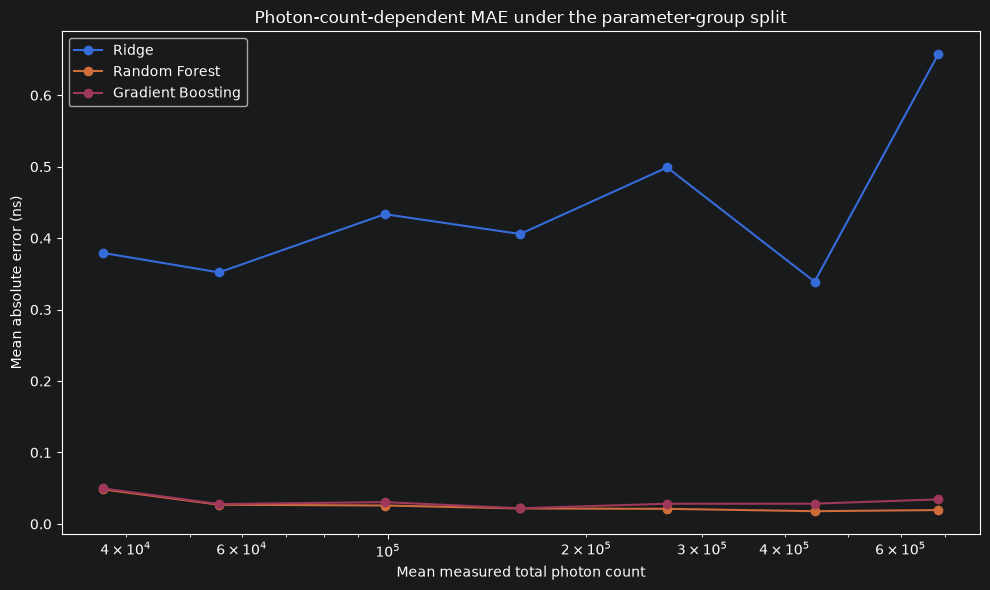

In [172]:
plt.figure(figsize=(10, 6))

for model_name in learned_model_names:
    model_summary = (
        photon_count_error_summary.loc[
            (
                photon_count_error_summary["protocol"]
                == "Parameter-group"
            )
            & (
                photon_count_error_summary["model"]
                == model_name
            )
        ]
        .sort_values("mean_total_counts")
    )

    plt.plot(
        model_summary["mean_total_counts"],
        model_summary["mae_ns"],
        marker="o",
        label=model_name,
    )

plt.xscale("log")
plt.xlabel("Mean measured total photon count")
plt.ylabel("Mean absolute error (ns)")
plt.title(
    "Photon-count-dependent MAE under the "
    "parameter-group split"
)
plt.legend()
plt.tight_layout()
plt.show()

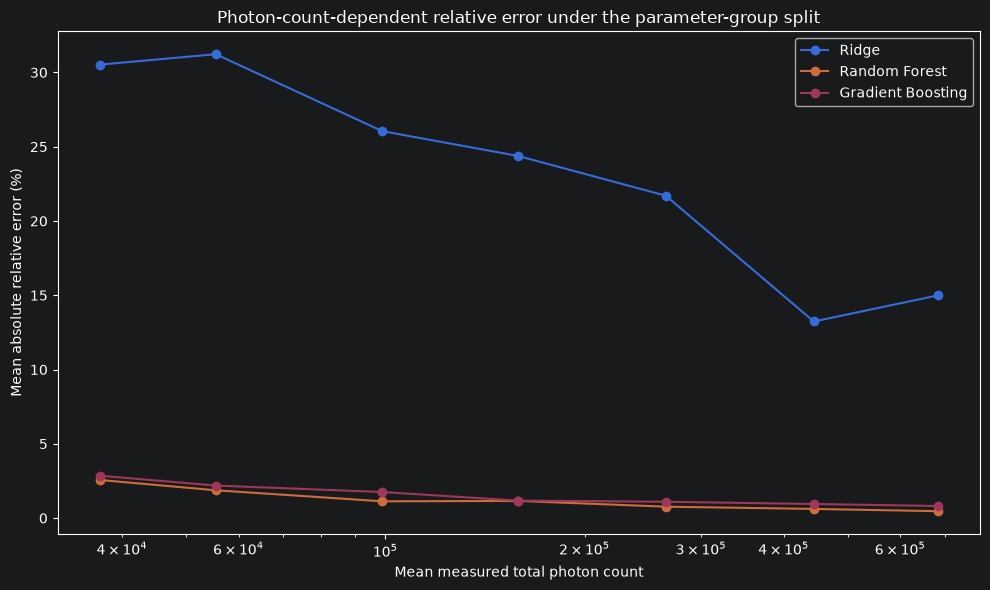

In [173]:
plt.figure(figsize=(10, 6))

for model_name in learned_model_names:
    model_summary = (
        photon_count_error_summary.loc[
            (
                photon_count_error_summary["protocol"]
                == "Parameter-group"
            )
            & (
                photon_count_error_summary["model"]
                == model_name
            )
        ]
        .sort_values("mean_total_counts")
    )

    plt.plot(
        model_summary["mean_total_counts"],
        model_summary[
            "mean_absolute_relative_error_percent"
        ],
        marker="o",
        label=model_name,
    )

plt.xscale("log")
plt.xlabel("Mean measured total photon count")
plt.ylabel("Mean absolute relative error (%)")
plt.title(
    "Photon-count-dependent relative error under the "
    "parameter-group split"
)
plt.legend()
plt.tight_layout()
plt.show()

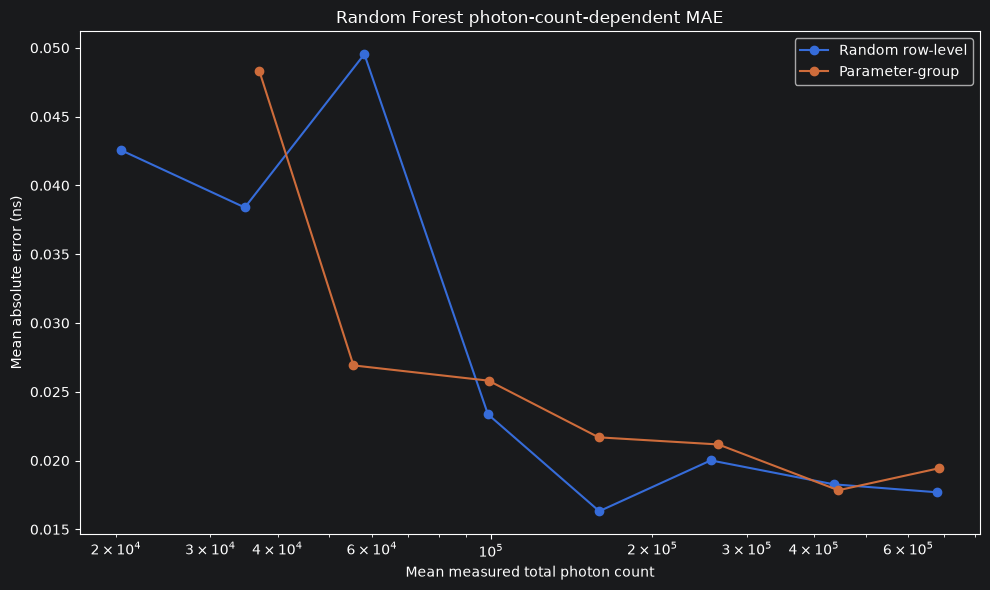

In [174]:
plt.figure(figsize=(10, 6))

for protocol_name in protocol_order:
    protocol_summary = (
        photon_count_error_summary.loc[
            (
                photon_count_error_summary["protocol"]
                == protocol_name
            )
            & (
                photon_count_error_summary["model"]
                == "Random Forest"
            )
        ]
        .sort_values("mean_total_counts")
    )

    plt.plot(
        protocol_summary["mean_total_counts"],
        protocol_summary["mae_ns"],
        marker="o",
        label=protocol_name,
    )

plt.xscale("log")
plt.xlabel("Mean measured total photon count")
plt.ylabel("Mean absolute error (ns)")
plt.title(
    "Random Forest photon-count-dependent MAE"
)
plt.legend()
plt.tight_layout()
plt.show()

In [175]:
grouped_count_bin_population = (
    photon_count_error_summary.loc[
        (
            photon_count_error_summary["protocol"]
            == "Parameter-group"
        )
        & (
            photon_count_error_summary["model"]
            == "Random Forest"
        ),
        [
            "photon_count_bin",
            "n_test_curves",
            "mean_total_counts",
        ],
    ]
    .sort_values("mean_total_counts")
)

grouped_count_bin_population

,photon_count_bin,n_test_curves,mean_total_counts
14,"(25379.989, 42464.489]",35,36989.885714
15,"(42464.489, 71049.393]",33,55421.878788
16,"(71049.393, 118876.182]",32,98952.000000
17,"(118876.182, 198897.499]",80,158750.800000
18,"(198897.499, 332785.04]",141,265363.950355
19,"(332785.04, 556798.772]",94,444191.765957
20,"(556798.772, 931607.0]",85,684414.870588


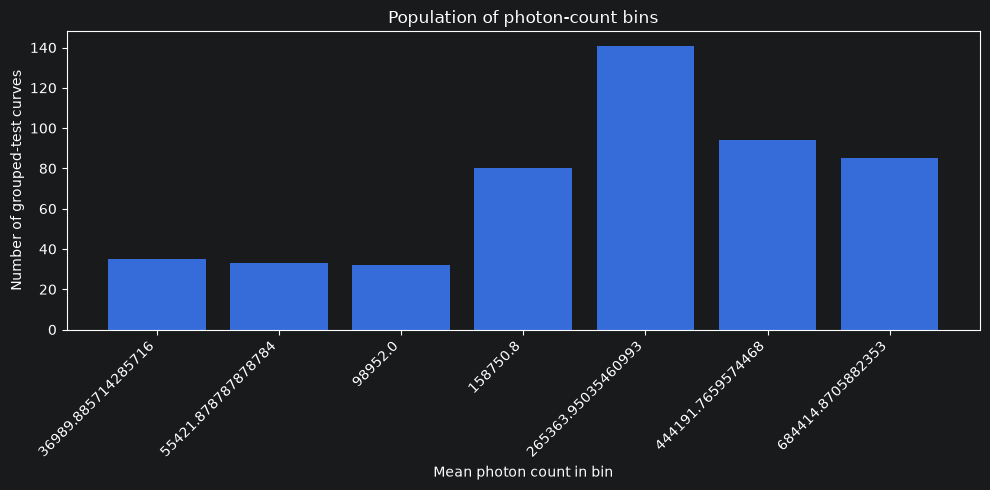

In [176]:
plt.figure(figsize=(10, 5))

plt.bar(
    grouped_count_bin_population[
        "mean_total_counts"
    ].astype(str),
    grouped_count_bin_population[
        "n_test_curves"
    ],
)

plt.xlabel("Mean photon count in bin")
plt.ylabel("Number of grouped-test curves")
plt.title(
    "Population of photon-count bins"
)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [177]:
grouped_random_forest_samples = (
    sample_errors.loc[
        (
            sample_errors["protocol"]
            == "Parameter-group"
        )
        & (
            sample_errors["model"]
            == "Random Forest"
        )
    ]
    .copy()
)

grouped_random_forest_samples[
    "photon_count_quantile"
] = pd.qcut(
    grouped_random_forest_samples[
        "measured_total_counts"
    ],
    q=5,
    duplicates="drop",
)

random_forest_count_quantiles = (
    grouped_random_forest_samples
    .groupby(
        "photon_count_quantile",
        observed=True,
    )
    .agg(
        n_test_curves=(
            "curve_id",
            "size",
        ),
        mean_total_counts=(
            "measured_total_counts",
            "mean",
        ),
        mean_true_lifetime_ns=(
            "true_lifetime_ns",
            "mean",
        ),
        mae_ns=(
            "absolute_error_ns",
            "mean",
        ),
        mean_absolute_relative_error_percent=(
            "absolute_relative_error_percent",
            "mean",
        ),
    )
    .reset_index()
)

random_forest_count_quantiles.round(
    {
        "mean_total_counts": 1,
        "mean_true_lifetime_ns": 3,
        "mae_ns": 4,
        "mean_absolute_relative_error_percent": 2,
    }
)

,photon_count_quantile,n_test_curves,mean_total_counts,mean_true_lifetime_ns,mae_ns,mean_absolute_relative_error_percent
0,"(28750.999, 119216.4]",100,62900.3,1.684,0.0341,1.88
1,"(119216.4, 213618.0]",100,167599.0,1.988,0.0197,1.04
2,"(213618.0, 308660.4]",100,265935.7,2.688,0.0205,0.77
3,"(308660.4, 543921.8]",100,402492.0,3.074,0.0222,0.72
4,"(543921.8, 809886.0]",100,664430.0,4.081,0.0182,0.44


### Identification of difficult test regions

The largest binned MAE values are extracted for the best model (= Random Forest) under the parameter-group protocol.

This identifies the lifetime and photon-count regions in which Random Forest is least accurate within the present simulation campaign.

In [178]:
worst_lifetime_row_index = (
    grouped_random_forest_lifetime_errors[
        "mae_ns"
    ].idxmax()
)

worst_lifetime_region = (
    grouped_random_forest_lifetime_errors.loc[
        worst_lifetime_row_index
    ]
)

worst_lifetime_region

protocol                                Parameter-group
model                                     Random Forest
lifetime_bin                                (4.1, 4.55]
n_test_curves                                        65
mean_true_lifetime_ns                          4.337513
mae_ns                                         0.046835
median_absolute_error_ns                       0.036206
mean_absolute_relative_error_percent            1.08024
mean_residual_ns                               0.014662
lifetime_bin_center_ns                            4.325
Name: 8, dtype: object

In [179]:
worst_count_row_index = (
    grouped_random_forest_count_errors[
        "mae_ns"
    ].idxmax()
)

worst_photon_count_region = (
    grouped_random_forest_count_errors.loc[
        worst_count_row_index
    ]
)

worst_photon_count_region

protocol                                       Parameter-group
model                                            Random Forest
photon_count_bin                        (25379.989, 42464.489]
n_test_curves                                               35
mean_total_counts                                 36989.885714
median_total_counts                                    37590.0
mean_true_lifetime_ns                                 1.769247
mae_ns                                                0.048329
median_absolute_error_ns                              0.018728
mean_absolute_relative_error_percent                   2.56505
mean_residual_ns                                       0.04026
Name: 0, dtype: object

In [180]:
conditional_performance_summary = pd.DataFrame(
    [
        {
            "analysis": "Lifetime",
            "region": str(
                worst_lifetime_region[
                    "lifetime_bin"
                ]
            ),
            "n_test_curves": int(
                worst_lifetime_region[
                    "n_test_curves"
                ]
            ),
            "mean_true_lifetime_ns": float(
                worst_lifetime_region[
                    "mean_true_lifetime_ns"
                ]
            ),
            "mean_total_counts": np.nan,
            "mae_ns": float(
                worst_lifetime_region["mae_ns"]
            ),
            "mean_absolute_relative_error_percent": float(
                worst_lifetime_region[
                    "mean_absolute_relative_error_percent"
                ]
            ),
        },
        {
            "analysis": "Photon count",
            "region": str(
                worst_photon_count_region[
                    "photon_count_bin"
                ]
            ),
            "n_test_curves": int(
                worst_photon_count_region[
                    "n_test_curves"
                ]
            ),
            "mean_true_lifetime_ns": float(
                worst_photon_count_region[
                    "mean_true_lifetime_ns"
                ]
            ),
            "mean_total_counts": float(
                worst_photon_count_region[
                    "mean_total_counts"
                ]
            ),
            "mae_ns": float(
                worst_photon_count_region[
                    "mae_ns"
                ]
            ),
            "mean_absolute_relative_error_percent": float(
                worst_photon_count_region[
                    "mean_absolute_relative_error_percent"
                ]
            ),
        },
    ]
)

conditional_performance_summary.round(
    {
        "mean_true_lifetime_ns": 3,
        "mean_total_counts": 1,
        "mae_ns": 4,
        "mean_absolute_relative_error_percent": 2,
    }
)

,analysis,region,n_test_curves,mean_true_lifetime_ns,mean_total_counts,mae_ns,mean_absolute_relative_error_percent
0,Lifetime,"(4.1, 4.55]",65,4.338,NaN,0.0468,1.08
1,Photon count,"(25379.989, 42464.489]",35,1.769,36989.9,0.0483,2.57


### Interpretation of conditional errors

Under the parameter-group split, Random Forest remains highly accurate across the investigated lifetime and photon-count ranges, although its error is not uniformly distributed.

The lifetime-dependent MAE does not increase monotonically with lifetime. Instead, it fluctuates across the lifetime range and shows a pronounced local maximum for long decays. The largest binned MAE occurs in the interval `(4.1, 4.55] ns`, which contains `65` test curves with a mean true lifetime of `4.338 ns`. In this interval, the MAE is `0.0468 ns`, the median absolute error is `0.0362 ns`, and the mean absolute relative error is `1.08%`.

The smallest absolute errors occur for the shortest-lifetime interval `(0.499, 0.95] ns`, where the MAE is `0.0094 ns`. However, the relative error in this interval is `1.45%`, illustrating that a small absolute deviation can still represent a noticeable fraction of a short lifetime. The largest mean absolute relative error across the lifetime bins is `1.51%` in the `(1.4, 1.85] ns` interval.

The photon-count-dependent analysis shows a clearer trend. Prediction error is largest in the lowest-count regime and generally decreases as the measured photon count increases. The largest binned MAE occurs in the interval `(25,379.989, 42,464.489]` measured photons, which contains `35` test curves with a mean total count of approximately `36,990`. In this interval, the MAE is `0.0483 ns`, the median absolute error is `0.0187 ns`, and the mean absolute relative error is `2.57%`.

At higher photon counts, the MAE decreases to `0.0178 ns` in the `(332,785.040, 556,798.772]` interval and then rises slightly to `0.0194 ns` in the highest-count interval. The relative error decreases more consistently, from `2.57%` in the lowest-count bin to `0.46%` in the highest-count bin. This pattern is consistent with the stronger relative Poisson fluctuations expected for lower-count curves. Nevertheless, photon count is correlated with amplitude, lifetime, and background in this simulation, so the observed trend should not be interpreted as a fully isolated causal effect of photon noise.

The signed residuals reveal small, lifetime-dependent changes in prediction bias. Random Forest slightly underestimates the shortest-lifetime bins, with mean residuals of `-0.0036 ns` and `-0.0007 ns`. It overestimates lifetimes in the `(1.4, 1.85] ns` interval by an average of `0.0143 ns`, remains nearly unbiased across much of the middle range, and again overestimates the `(4.1, 4.55] ns` interval by `0.0147 ns`. In the longest-lifetime interval, `(4.55, 5.0] ns`, the mean residual changes sign to `-0.0108 ns`, indicating underestimation.

These changes in residual sign show that the small global mean residual does not imply uniform absence of bias. Positive and negative regional biases partly cancel when averaged over the complete test set.


### Final conclusions and limitations

This notebook demonstrated that train–test construction is part of the scientific definition of machine-learning performance.

The naive row-level split produced disjoint sets of measured histograms, but it did not produce independent sets of underlying simulation cases. Different Poisson realizations of the same lifetime–amplitude–background combination were frequently distributed between training and testing. Nearly all parameter groups represented in the random test set were therefore already represented by related curves during training.

The parameter-group split removed this dependence by keeping all five Poisson realizations of each expected decay together. Its training and test group sets were completely disjoint while retaining the same numbers of training and test curves as the random protocol.

All learned models outperformed the mean-prediction baseline. Random Forest gave the best overall results under both protocols, with an MAE of `0.0220 ns` under the random row-level split and `0.0229 ns` under the parameter-group split. Gradient Boosting followed closely, while Ridge regression was substantially less accurate.

The grouped split increased MAE by approximately:

* `4.1%` for Ridge;
* `4.0%` for Random Forest;
* `10.3%` for Gradient Boosting.

The random row-level split was therefore slightly optimistic, although the effect was not dramatic for this idealized dataset. Random Forest and Gradient Boosting retained excellent interpolation performance for parameter combinations absent from training but drawn from the same overall simulation ranges.

The lifetime- and photon-count-dependent analyses provide a more detailed view than the global metrics alone. They reveal whether errors are distributed uniformly or concentrated in particular lifetime and count regimes. These conditional results should always be interpreted together with the number of test curves in each bin and with possible correlations among lifetime, amplitude, background, and total photon count.

The present conclusions are limited to the simulated conditions used in this notebook:

* mono-exponential fluorescence decays;
* Poisson photon-count statistics;
* no instrument-response-function convolution;
* a fixed time axis and acquisition window;
* uniformly sampled lifetime, amplitude, and background ranges;
* normalized raw histogram bins as model inputs;
* one simulation campaign and one train–test split;
* no hyperparameter optimization;
* no experimental TCSPC data.

The parameter-group test measures interpolation to unfamiliar combinations within familiar parameter ranges. It does not yet demonstrate:

* extrapolation beyond the trained lifetime range;
* robustness to deliberately unseen photon-count regimes;
* robustness to biexponential or otherwise mismatched decay models;
* robustness to pile-up, afterpulsing, timing offsets, or nonconstant backgrounds;
* robustness to unfamiliar or experimentally measured IRFs;
* transfer from synthetic to experimental measurements.

Future evaluation should therefore separate several claims explicitly:

1. interpolation to unseen parameter combinations;
2. robustness to new photon-count and background regimes;
3. extrapolation to held-out lifetime intervals;
4. robustness to physical model mismatch;
5. robustness to unfamiliar IRFs;
6. transfer to independently acquired experimental data.

The principal lesson is that a low test error is meaningful only when the test set represents the type of generalization being claimed. For the current toolkit, the parameter-group split provides the more scientifically defensible baseline for evaluating interpolation performance.

